<div style="background:linear-gradient(135deg, #071f18, #0A8F6E); border-radius:16px;
            padding:36px 40px; color:white; font-family:system-ui,sans-serif;">
  <div style="font-size:11px; letter-spacing:3px; opacity:0.5; margin-bottom:12px;">MODULE 2 — DEEP LEARNING VISION — TRACK K — 10H EN CLASSE</div>
  <div style="font-size:32px; font-weight:800; line-height:1.2; margin-bottom:12px;">Détecteur de Dommages Véhicules</div>
  <div style="font-size:15px; opacity:0.75; max-width:620px; line-height:1.6; margin-bottom:20px;">
    Fine-tuning MobileNet-V2 -- Détection dommages auto -- GradCAM -- Interface expertise Gradio<br>
    Du dataset brut a une application déployée.</div>
  <div style="display:flex; gap:10px; flex-wrap:wrap;">
    <span style="background:rgba(255,255,255,0.1); padding:5px 14px; border-radius:20px; font-size:12px;">9 étapes guidées</span>
    <span style="background:rgba(255,255,255,0.1); padding:5px 14px; border-radius:20px; font-size:12px;">Cible : AUC > 0.88</span>
    <span style="background:rgba(255,255,255,0.1); padding:5px 14px; border-radius:20px; font-size:12px;">Interface déployée</span>
    <span style="background:rgba(255,255,255,0.1); padding:5px 14px; border-radius:20px; font-size:12px;">Assurance automobile</span></div>
</div>

<div style="background:#f8f9fa; border:1px solid #dee2e6; border-radius:12px;
            padding:22px 26px; font-family:system-ui,sans-serif;">
  <div style="font-size:15px; font-weight:700; color:#212529; margin-bottom:14px;">Contexte</div>
  <div style="font-size:13.5px; color:#495057; line-height:1.75; margin-bottom:16px;">
        Vous êtes ingénieur IA dans une compagnie d'assurance automobile. Le directeur des sinistres vous demande :
    <em>"Nos experts terrain sont débordés — 3 semaines d'attente pour un constat. Peut-on pré-évaluer
    les dommages a partir des photos que les assures envoient depuis leur smartphone ?"</em><br><br>
    Votre mission : construire un modèle de détection de dommages sur photos de véhicules,
    vérifier qu'il regarde les zones endommagées, et créer une interface de déclaration en ligne.</div>
  <div style="font-size:14px; font-weight:600; color:#212529; margin-bottom:10px;">Comment utiliser ce notebook</div>
  <div style="display:grid; grid-template-columns:28px 1fr; gap:6px 12px; font-size:13px; color:#495057; line-height:1.7;">
    <span style="font-weight:700; color:#0A8F6E;">1.</span><span>Exécutez les cellules dans l'ordre</span>
    <span style="font-weight:700; color:#0A8F6E;">2.</span><span><span style="color:#131fcf;font-weight:600;">Prompts bleus</span> = du code a écrire dans la cellule vide en dessous</span>
    <span style="font-weight:700; color:#0A8F6E;">3.</span><span><span style="color:#7a0f43;font-weight:600;">Questions rouges</span> = réflexion a rédiger en commentaire Python</span>
    <span style="font-weight:700; color:#0A8F6E;">4.</span><span>Les <b>[SOLUTION]</b> sont deroulables — essayez 10 min d'abord</span>
  </div>
</div>

<div style="border:2px solid #0A8F6E;border-radius:14px;overflow:hidden;margin:20px 0;font-family:system-ui,sans-serif;">
  <div style="background:#0A8F6E;padding:14px 22px;display:flex;align-items:center;gap:12px;">
    <span style="font-size:24px;">🖼️</span>
    <div>
      <div style="font-size:16px;font-weight:700;color:white;">Dataset : Car Damage Detection Dataset</div>
      <div style="font-size:12px;color:rgba(255,255,255,0.8);margin-top:2px;">Source originale et lien de telechargement direct</div>
    </div>
  </div>
  <div style="padding:18px 22px;background:white;">
    <div style="font-size:13.5px;color:#333;line-height:1.8;margin-bottom:14px;">~2 000 images couleur de vehicules prises en conditions reelles (smartphone). Deux classes : <b>DAMAGED</b> (vehicule endommage) et <b>NOT DAMAGED</b> (vehicule intact).</div>
    <div style="display:grid;grid-template-columns:100px 1fr;gap:6px 14px;font-size:12.5px;color:#495057;line-height:1.7;">
      <span style="font-weight:700;color:#0A8F6E;">Source</span><span>Kaggle — anujms/car-damage-detection</span>
      <span style="font-weight:700;color:#0A8F6E;">Volume</span><span>~2 000 images couleur, conditions reelles</span>
      <span style="font-weight:700;color:#0A8F6E;">URL originale</span><span><a href="https://www.kaggle.com/datasets/anujms/car-damage-detection" target="_blank" style="color:#0A8F6E;text-decoration:none;">https://www.kaggle.com/datasets/anujms/car-damage-detection</a></span>
    </div>
    <div style="margin-top:14px;padding-top:12px;border-top:1px solid #eee;"><div style="display:flex;align-items:flex-start;gap:10px;margin:8px 0;"><span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#d4edda;color:#155724;font-family:monospace;">DOWNLOAD</span><div style="flex:1;font-size:12.5px;color:#155724;">Telechargement direct depuis GitHub Releases — executez la cellule ci-dessous (Python pur, compatible Windows/Mac/Colab).</div></div></div>
  </div>
</div>

In [1]:
# ============================================================
# TELECHARGEMENT DU DATASET
# ============================================================
# Source : Kaggle — anujms/car-damage-detection
# Telechargement direct (Python pur — compatible Windows/Mac/Colab)

import os, zipfile, urllib.request, shutil, random

zip_name = "Car-Damage-Detection.zip"
url = "https://github.com/archiducarmel/SupDeVinci_M1_MachineLearning_DeepLearning/releases/download/datas/Car-Damage-Detection.zip"
data_dir = "car_damage"

if os.path.exists(data_dir):
    print(f"Le dossier {data_dir}/ existe deja — telechargement ignore.")
else:
    print(f"Telechargement de {zip_name}...")
    urllib.request.urlretrieve(url, zip_name)
    print("Decompression...")
    with zipfile.ZipFile(zip_name, 'r') as z:
        z.extractall('.')

# Le ZIP extrait les donnees dans : data1a/
# On le renomme vers le chemin attendu : car_damage/
if os.path.exists("data1a") and not os.path.exists("car_damage"):
    shutil.move("data1a", "car_damage")
    os.remove(zip_name)
    print("Nettoyage OK.")

# ============================================================
# CREATION DU SPLIT TESTING (20% de validation)
# ============================================================
val_dir  = os.path.join(data_dir, "validation")
test_dir = os.path.join(data_dir, "testing")

if os.path.exists(val_dir) and not os.path.exists(test_dir):
    print("\nCréation du dossier testing a partir de validation (80/20)...")
    random.seed(42)

    for cls in sorted(os.listdir(val_dir)):
        cls_val_path  = os.path.join(val_dir, cls)
        cls_test_path = os.path.join(test_dir, cls)

        if not os.path.isdir(cls_val_path):
            continue

        os.makedirs(cls_test_path, exist_ok=True)

        images = sorted([
            f for f in os.listdir(cls_val_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))
        ])
        random.shuffle(images)

        n_test = max(1, int(len(images) * 0.20))
        for fname in images[:n_test]:
            shutil.move(
                os.path.join(cls_val_path, fname),
                os.path.join(cls_test_path, fname)
            )

        print(f"  '{cls}' : {len(images) - n_test} images en validation | {n_test} images en testing")

    print("Split testing créé.")
else:
    if not os.path.exists(val_dir):
        print("Dossier validation/ introuvable : vérifiez l'extraction du ZIP.")
    else:
        print("Dossier testing/ déjà présent : split ignoré.")

# ============================================================
# VERIFICATION FINALE
# ============================================================
print(f"\n Contenu de {data_dir}/ :")
for split in ["training", "validation", "testing"]:
    path = os.path.join(data_dir, split)
    if os.path.exists(path):
        n = sum(len(files) for _, _, files in os.walk(path))
        classes = sorted(os.listdir(path))
        print(f"  {split:10s} : {n:>5d} images | classes : {classes}")
    else:
        print(f"  {split:10s} : ABSENT")
print(f"\n Donnees pretes dans ./{data_dir}/")

Telechargement de Car-Damage-Detection.zip...
Decompression...
Nettoyage OK.

Création du dossier testing a partir de validation (80/20)...
  '00-damage' : 184 images en validation | 46 images en testing
  '01-whole' : 184 images en validation | 46 images en testing
Split testing créé.

 Contenu de car_damage/ :
  training   :  1840 images | classes : ['00-damage', '01-whole']
  validation :   368 images | classes : ['00-damage', '01-whole']
  testing    :    92 images | classes : ['00-damage', '01-whole']

 Donnees pretes dans ./car_damage/


<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 01/09 — 30 MIN</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">Découverte du dataset</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">Voir les données avant de modéliser. Comprendre ce qu'on regarde, détecter les biais, anticiper les difficultés.</div></div>

<div style="border-left:4px solid #0A8F6E;background:#0A8F6E0a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0A8F6E;margin-bottom:8px;">Pourquoi explorer les images avant tout ?</div><div style="font-size:13.5px;color:#333;line-height:1.8;">En deep learning vision, les données sont des <b>images</b>. Avant de lancer un modèle, trois choses sont indispensables :<br><b>1.</b> <b>Voir</b> a quoi ressemblent les images de chaque classe — les différences sont-elles visibles a l'oeil nu ?<br><b>2.</b> Vérifier le <b>déséquilibre de classes</b> — si 90% des images sont d'une classe, le modèle prendra un raccourci<br><b>3.</b> Observer la <b>qualité et variété</b> des images — taille, éclairage, cadrage, artefacts<br><br><em>Cette étape est la fondation de tout le projet. Un modèle entraîne sur des données biaisées ou mal comprises produira des résultats trompeurs.</em></div></div>

In [2]:
# ------------------------------------------------------------------
# Imports et configuration
# ------------------------------------------------------------------
import torch
import torchvision
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import numpy as np
import os
from IPython.display import HTML, display
from collections import Counter

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
if device.type == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
else:
    print("Pas de GPU — l'entrainement sera plus lent mais fonctionnera.")


Device : cuda
GPU    : Tesla T4


<div style="border-left:4px solid #2d5986;background:#2d59860a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#2d5986;margin-bottom:8px;">Le dataset : Car Damage Detection Dataset</div><div style="font-size:13.5px;color:#333;line-height:1.8;"><div style='display:grid;grid-template-columns:1fr 1fr;gap:10px;'>
<div style='background:#f0f0f0;border-radius:8px;padding:12px;text-align:center;'>
<b style='color:#c0392b;'>DAMAGED</b><br>Dommage visible sur le vehicule<br>(bosse, rayure, vitre cassee, deformation)</div>
<div style='background:#f0f0f0;border-radius:8px;padding:12px;text-align:center;'>
<b style='color:#28a745;'>NOT DAMAGED</b><br>Vehicule intact, pas de dommage visible<br>sur la photo</div></div><br><br>Source : <b>Kaggle: anujms/car-damage-detection</b><br>Volume : ~2 000 images couleur, conditions reelles (smartphone)</div></div>

In [3]:
# ------------------------------------------------------------------
# Charger le dataset
# ------------------------------------------------------------------
# Structure attendue :
#   car_damage/
#     training/
#       damaged/
#       not_damaged/
#     validation/
#       damaged/
#       not_damaged/
#     testing/
#       damaged/
#       not_damaged/

data_dir = 'car_damage'  # Adapter selon votre environnement

train_raw = datasets.ImageFolder(os.path.join(data_dir, 'training'))
val_raw = datasets.ImageFolder(os.path.join(data_dir, 'validation'))
test_raw = datasets.ImageFolder(os.path.join(data_dir, 'testing'))

print(f"Classes : {train_raw.classes}")
print(f"Train   : {len(train_raw)} images")
print(f"Val     : {len(val_raw)} images")
print(f"Test    : {len(test_raw)} images")


Classes : ['00-damage', '01-whole']
Train   : 1840 images
Val     : 368 images
Test    : 92 images


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Compter les images par classe.</b> L'objectif est de détecter un éventuel déséquilibre qui pourrait biaiser le modèle. Utiliser <code>Counter(train_raw.targets)</code> pour compter les images de chaque classe. Afficher les résultats. Vérifier l'équilibre damaged/not_damaged. Le dataset est généralement assez équilibre. Un modèle entraîne sur un dataset déséquilibre risque de toujours prédire la classe majoritaire — il obtient un bon score sans rien avoir appris.</span></p>

In [4]:
from collections import Counter

for name, ds in [('Training', train_raw), ('Validation', val_raw), ('Testing', test_raw)]:
    counts = Counter(ds.targets)
    total  = len(ds)
    print(f"\n{name}:")
    for idx, cls in enumerate(ds.classes):
        n = counts[idx]
        print(f"  {cls:15s} : {n:>5d} images ({n/total*100:.1f}%)")

# Verification equilibre
counts_train = Counter(train_raw.targets)
ratio = max(counts_train.values()) / min(counts_train.values())
print(f"\nRatio max/min (train) : {ratio:.2f}  ", end="")
print("(equilibre)" if ratio < 1.5 else "(DESEQUILIBRE — envisager WeightedSampler)")



Training:
  00-damage       :   920 images (50.0%)
  01-whole        :   920 images (50.0%)

Validation:
  00-damage       :   184 images (50.0%)
  01-whole        :   184 images (50.0%)

Testing:
  00-damage       :    46 images (50.0%)
  01-whole        :    46 images (50.0%)

Ratio max/min (train) : 1.00  (equilibre)


In [5]:
# Votre code ici
print(Counter(train_raw.targets))
print(Counter(val_raw.targets))
print(Counter(test_raw.targets))

Counter({0: 920, 1: 920})
Counter({0: 184, 1: 184})
Counter({0: 46, 1: 46})


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.ImageFolder.html" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">torchvision.datasets.ImageFolder</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Documentation officielle — structure attendue des dossiers, paramètres disponibles</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://towardsdatascience.com/handling-imbalanced-datasets-in-deep-learning-f48407a0e758/" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Handling Imbalanced Datasets in Deep Learning</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Pourquoi le déséquilibre de classes est dangereux et comment le gérer</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Déséquilibre et contexte business.</b> (1) Le dataset est-il équilibre ? (2) En assurance, qu'est-ce qui coûte le plus cher : déclarer un véhicule intact comme endommage (faux positif — payer une réparation non nécessaire) ou déclarer un véhicule endommage comme intact (faux négatif — le client est mécontent, litige) ? (3) Le risque de fraude (envoyer la photo d'un autre véhicule) est-il un problème ?</span></p>

In [6]:
# Votre reponse ici
# 1/ Le dataset est parfaitement équilibré 50/50
# 2/ En assurance, on préfère souvent un modèle sensible (qui détecte tout, quitte à faire quelques faux positifs) plutôt qu'un modèle trop "strict".
# On cherche à maximiser le Rappel (Recall) pour la classe "Damage".
# 3/ La fraude est un risque réel : envoyer la photo d'un véhicule déjà endommagé
#     avant l'accident est une fraude classique. Un système de vérification d'identité
#     du véhicule (plaque, VIN) serait nécessaire en production.

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Visualiser des exemples de chaque classe.</b> L'objectif est de développer votre intuition visuelle sur les données — avant même que le modèle ne les voie. Afficher une grille d'images : 8 images par classe sur des lignes separees. Utiliser <code>plt.subplots</code>. Pour chaque image : <code>img, label = train_raw[index]</code> puis <code>imshow(img)</code>. Ajouter le nom de la classe en titre. Observez attentivement : voyez-vous les différences ?</span></p>

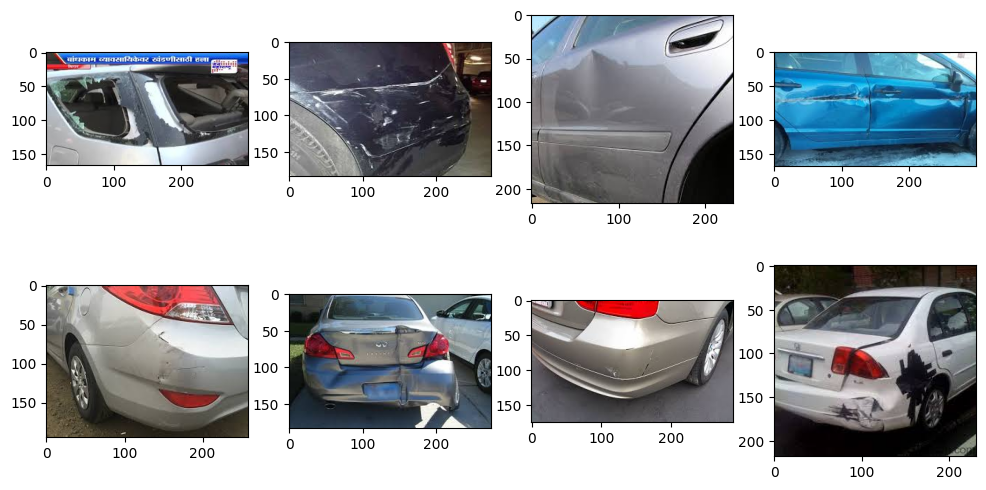

In [7]:
# Votre code ici
plt.subplots(2, 4, figsize=(12, 6))
for i in range(8):
    img, label = train_raw[i]
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)

<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">matplotlib.pyplot.subplots</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Référence pour créer des grilles d'images avec subplots</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#f3e5f5;color:#6c3483;font-family:monospace;flex-shrink:0;white-space:nowrap;">TUTO</span>
<div style="flex:1;"><a href="https://docs.pytorch.org/tutorials/beginner/data_loading_tutorial.html" target="_blank" style="font-size:12.5px;color:#6c3483;font-weight:600;text-decoration:none;">Visualizing image datasets in PyTorch</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Tutorial officiel PyTorch sur le chargement et la visualisation de datasets d'images</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Observer les véhicules.</b> (1) Les dommages sont-ils toujours évidents (grosse bosse, pare-chocs arrache) ou parfois subtils (petite rayure, micro-fissure) ? (2) Les photos sont-elles prises dans des conditions contrôlées (garage) ou en conditions réelles (parking, rue, nuit) ? (3) L'arrière-plan (autres voitures, bâtiments, reflets) risque-t-il de tromper le modèle ?</span></p>

In [8]:
# Votre reponse ici
# 1/ Les dégats sur les véhicuules peuvent-être très subtils (érraflures)
# 2/ L'environnement de la photo n'est pas le même, l'angle non plus
# 3/ Oui absolument

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Vérifier la taille des images.</b> Les images du dataset n'ont pas nécessairement toutes la même taille. Afficher la taille de 5 images avec <code>train_raw[i][0].size</code>. Si les tailles varient, c'est normal — l'étape 2 (Resize) uniformisera tout. Mais c'est important de le savoir avant, car cela explique pourquoi le preprocessing est indispensable.</span></p>

In [9]:
# votre code ici
print("Tailles de 5 images du training set :")
for i in range(5):
    img, label = train_raw[i]
    print(f"  Image {i} ({train_raw.classes[label]:15s}) : {img.size[0]}x{img.size[1]} px")

# Collecte des tailles uniques sur 50 images
sizes = set()
for i in range(min(50, len(train_raw))):
    img, _ = train_raw[i]
    sizes.add(img.size)
print(f"\nTailles uniques sur 50 images : {len(sizes)} tailles différentes")


Tailles de 5 images du training set :
  Image 0 (00-damage      ) : 300x168 px
  Image 1 (00-damage      ) : 275x183 px
  Image 2 (00-damage      ) : 233x217 px
  Image 3 (00-damage      ) : 299x168 px
  Image 4 (00-damage      ) : 259x194 px

Tailles uniques sur 50 images : 22 tailles différentes


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Calculer la taille totale du dataset en mégaoctets.</b> L'objectif est de comprendre la 'quantité' de données que le modèle devra traiter. Pour une image de taille WxHx3 canaux, le nombre de valeurs = W*H*3. Multipliez par le nombre d'images du train set. Ce chiffre explique pourquoi on a besoin de GPUs : un CPU serait trop lent pour traiter autant de données des milliers de fois (epochs).</span></p>

In [10]:
# Taille totale du training set en mégaoctets
import numpy as np

img_sample, _ = train_raw[0]
W, H = img_sample.size  # PIL Image
pixels_per_image = W * H * 3  # 3 canaux RGB
nb_images = len(train_raw)
total_values = pixels_per_image * nb_images
total_mb = total_values / (1024 ** 2)

print(f"Résolution d'une image : {W}x{H} px")
print(f"Valeurs par image      : {pixels_per_image:,} (W x H x 3 canaux)")
print(f"Nombre d'images        : {nb_images:,}")
print(f"Total valeurs          : {total_values:,}")
print(f"Taille totale          : {total_mb:.1f} Mo (avant normalisation float32)")
print("=> En float32 (4 octets), ça représente", f"{total_mb * 4:.0f} Mo en RAM.")
print("=> Le GPU permet de traiter ces données 100x plus vite qu'un CPU.")


Résolution d'une image : 300x168 px
Valeurs par image      : 151,200 (W x H x 3 canaux)
Nombre d'images        : 1,840
Total valeurs          : 278,208,000
Taille totale          : 265.3 Mo (avant normalisation float32)
=> En float32 (4 octets), ça représente 1061 Mo en RAM.
=> Le GPU permet de traiter ces données 100x plus vite qu'un CPU.


In [11]:
# CHECKPOINT — Etape 1
assert len(train_raw.classes) == 2
display(HTML('<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 1 validee.</b> <span style="color:#1e5631;">Dataset explore. Classes et desequilibre identifies.</span></div>'))


<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 02/09 — 30 MIN</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">Transforms et DataLoaders</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">Préparer les images pour le ViT : taille fixe, normalisation, augmentation. C'est le pipeline de preprocessing.</div></div>

<div style="border-left:4px solid #0A8F6E;background:#0A8F6E0a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0A8F6E;margin-bottom:8px;">Pourquoi transformer les images ?</div><div style="font-size:13.5px;color:#333;line-height:1.8;">Le ViT attend des images dans un format précis :<br><b>1. Taille fixe 224x224</b> — toutes les images doivent avoir la même taille<br><b>2. 3 canaux RGB</b><br><b>3. Normalisation ImageNet</b> : mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225] — ce sont les statistiques du dataset original du ViT. Les utiliser permet au modèle de retrouver ses repères.<br><b>4. Tenseur PyTorch</b> — conversion du format image (PIL) au format calcul (tenseur)<br><br><em>Analogie : c'est comme traduire un texte dans la langue du modèle. Si on ne normalise pas correctement, le modèle reçoit des données dans un 'dialecte' qu'il ne comprend pas.</em></div></div>

<div style="border-left:4px solid #e67e22;background:#e67e220a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#e67e22;margin-bottom:8px;">Data augmentation — plus de variété pour mieux généraliser</div><div style="font-size:13.5px;color:#333;line-height:1.8;">Le data augmentation applique des transformations aléatoires (flip, rotation, recadrage) aux images d'entraînement pour créer de la diversité artificielle.<br><br><b>Objectif :</b> empêcher le modèle de mémoriser les images exactes. S'il voit la même image sous différents angles, il apprend les CARACTÉRISTIQUES du sujet, pas la photo spécifique.<br><br><b>Règle d'or :</b> l'augmentation ne s'applique <b>JAMAIS au val/test</b>. Pourquoi ? L'évaluation doit se faire sur les images réelles, pas sur des versions deformees.<br><br><em>Analogie : un étudiant qui s'entraîne sur des variantes d'exercices (chiffres différents, contextes différents) apprend mieux que celui qui refait le même exercice 50 fois.</em></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Définir les transforms pour le train set.</b> L'objectif est de créer le pipeline de preprocessing complet qui transforme une image brute en tenseur prêt pour le ViT. Enchaîner dans un <code>transforms.Compose</code> : <code>Resize((224, 224))</code>, <code>RandomHorizontalFlip()</code>, <code>RandomRotation(10)</code>, <code>ToTensor()</code>, <code>Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])</code>. Chaque opération a un rôle précis — ne sautez aucune étape.</span></p>

In [12]:
# Votre code ici
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://docs.pytorch.org/vision/stable/transforms.html" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">torchvision.transforms</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Liste complète des transformations disponibles : Resize, Normalize, RandomFlip, etc.</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://neptune.ai/blog/data-augmentation-in-pytorch" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Data Augmentation in PyTorch</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Guide complet sur l'augmentation de données avec exemples visuels</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://docs.pytorch.org/vision/stable/models.html" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">ImageNet normalization values</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Pourquoi mean=[0.485,0.456,0.406] et std=[0.229,0.224,0.225] — statistiques du dataset original</div></div></div></div>

<div style="border-left:4px solid #d4a017;background:#fef9e7;border-radius:0 8px 8px 0;padding:14px 20px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:13px;font-weight:600;color:#7d6608;">Attention</div><div style="font-size:13px;color:#6e5b08;line-height:1.7;margin-top:4px;">L'augmentation (<code>RandomHorizontalFlip</code>, <code>RandomRotation</code>) ne s'applique qu'au <b>train</b>. Le val et le test utilisent le même pipeline SANS augmentation. Sinon, l'évaluation est faussée — vous mesureriez la performance sur des images deformees qui n'existent pas dans la réalité.</div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Définir les transforms pour val et test.</b> Même pipeline que le train mais SANS les augmentations aléatoires. Garder uniquement : <code>Resize((224, 224))</code>, <code>ToTensor()</code>, <code>Normalize(...)</code>. C'est le pipeline 'propre' qui sera utilisé pour l'évaluation et en production.</span></p>

In [13]:
# Votre code ici
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
# On réutilise val_transform pour le test (même pipeline sans augmentation)
test_transform = val_transform
print("Val/test transform défini.")


Val/test transform défini.


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Créer les datasets et DataLoaders.</b> Recharger les ImageFolder avec les transforms, puis créer les DataLoaders (batch_size=16, shuffle=True pour train, False pour val/test). Le DataLoader découpe le dataset en mini-lots que le modèle traitera un par un pendant l'entraînement.</span></p>

In [14]:
from torch.utils.data import DataLoader
from torchvision import datasets

# Recharger les ImageFolder avec les transforms
train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'training'),   transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(data_dir, 'validation'), transform=val_transform)
test_dataset  = datasets.ImageFolder(os.path.join(data_dir, 'testing'),    transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train : {len(train_dataset)} images | {len(train_loader)} batches")
print(f"Val   : {len(val_dataset)} images | {len(val_loader)} batches")
print(f"Test  : {len(test_dataset)} images | {len(test_loader)} batches")


Train : 1840 images | 115 batches
Val   : 368 images | 23 batches
Test  : 92 images | 6 batches


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://docs.pytorch.org/stable/data.html#torch.utils.data.DataLoader" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">torch.utils.data.DataLoader</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Documentation officielle — batch_size, shuffle, num_workers expliques</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Visualiser un batch transforme.</b> L'objectif est de vérifier que le pipeline de preprocessing fonctionne correctement avant de lancer l'entraînement.<br><br>(1) Charger un batch depuis le DataLoader en utilisant la fonction <b>next</b> sur un itérateur du loader<br>(2) Afficher la forme du batch d'images — elle devrait être [batch_size, 3, 224, 224]<br>(3) Afficher quelques images du batch en utilisant matplotlib. Attention : il faut d'abord dénormaliser les images (inverser la normalisation) et transposer les dimensions (de [C,H,W] a [H,W,C]) pour que matplotlib puisse les afficher<br>(4) Vérifier que les images sont reconnaissables et que les labels correspondent<br><br><em>Cette vérification évité de découvrir un bug de preprocessing après 30 minutes d'entraînement. Si les images sont toutes noires, entièrement bleues, ou deformees, c'est le moment de corriger les transforms.</em></span></p>

Shape du batch : torch.Size([16, 3, 224, 224])  # [batch, canaux, H, W]


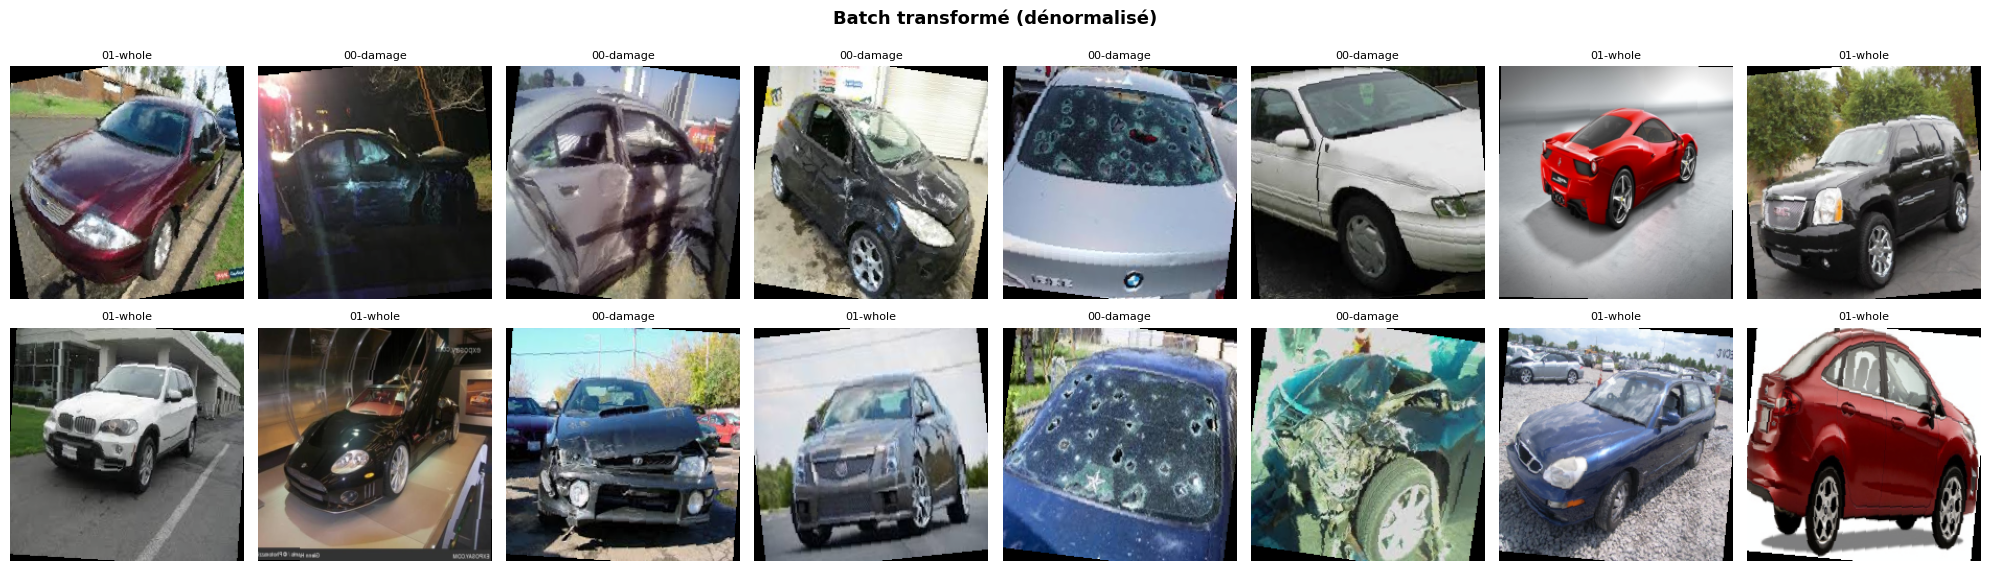

In [15]:
# Votre code ici
# Visualiser un batch transformé
import matplotlib.pyplot as plt
import numpy as np

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

def denormalize(tensor):
    img = tensor.permute(1, 2, 0).numpy()
    return np.clip(img * std + mean, 0, 1)

images, labels = next(iter(train_loader))
print(f"Shape du batch : {images.shape}  # [batch, canaux, H, W]")

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
fig.suptitle('Batch transformé (dénormalisé)', fontsize=13, fontweight='bold')
for i, ax in enumerate(axes.flatten()):
    if i < len(images):
        ax.imshow(denormalize(images[i]))
        ax.set_title(train_dataset.classes[labels[i].item()], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Visualiser l'augmentation sur une même image.</b> L'objectif est de voir concrètement ce que fait le data augmentation. Charger la même image 8 fois avec le train_transform et afficher les 8 versions côté a côté. Chaque version sera légèrement différente (flip, rotation). Cela montre la diversité artificielle créée par l'augmentation.</span></p>

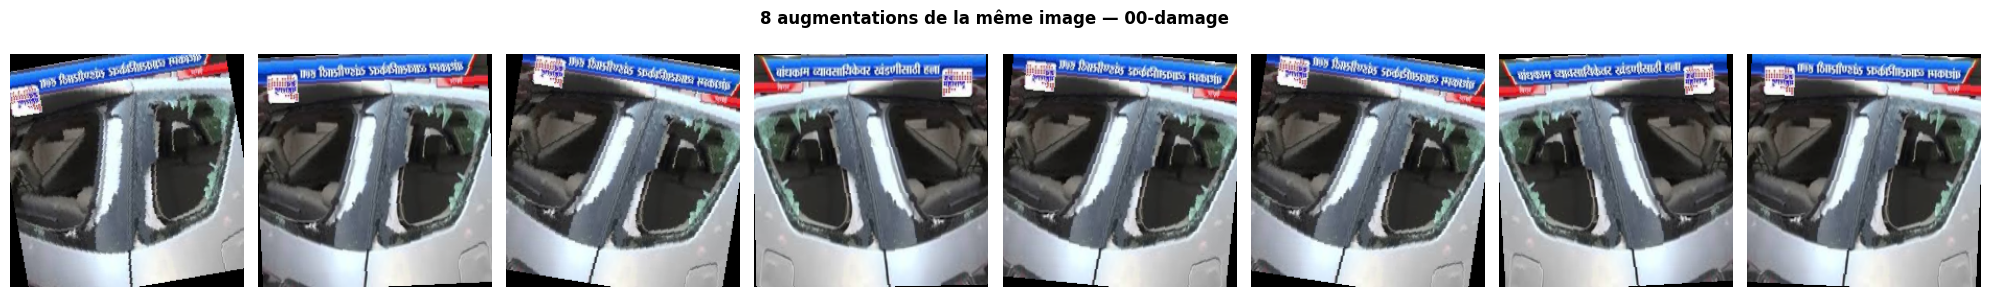

In [16]:
# Votre code ici
# 8 versions augmentées de la même image
from PIL import Image as PILImage

img_path = train_raw.imgs[0][0]
raw_pil  = PILImage.open(img_path).convert('RGB')

fig, axes = plt.subplots(1, 8, figsize=(20, 3))
fig.suptitle(f'8 augmentations de la même image — {train_raw.classes[train_raw.imgs[0][1]]}',
             fontsize=12, fontweight='bold')
for ax in axes:
    tensor = train_transform(raw_pil)
    ax.imshow(denormalize(tensor))
    ax.axis('off')
plt.tight_layout()
plt.show()


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Comprendre le batch et l'augmentation.</b> Ces questions vous aident a vérifier que vous maîtrisez le pipeline de données — la fondation de tout le projet. (1) Quelle est la shape du tenseur <code>images</code> ? (elle devrait être [16, 3, 224, 224] = batch x canaux x H x W). (2) Pourquoi <code>shuffle=True</code> pour le train ? (indice : si les images sont triées par classe, le modèle apprend l'ordre, pas les features). (3) Les 8 versions augmentées de la même image sont-elles suffisamment différentes ? L'augmentation change-t-elle le sens de l'image dans votre domaine ?</span></p>

In [17]:
# Votre reponse ici
# 1/ Shape : [16, 3, 224, 224] = batch_size x canaux x H x W.
# 2/ shuffle=True pour le train : sans mélange, le modèle verrait tous les
#     'damaged' d'abord, puis tous les 'not_damaged'. Ses mises à jour de poids
#     seraient biaisées class par class. Le mélange assure un gradient représentatif.
# 3/ Les augmentations (flip, rotation, luminosité) sont réalistes pour des photos
#     de véhicule prises au smartphone. Elles n'altèrent pas le sens de l'image.


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Adapter l'augmentation a votre domaine.</b> L'augmentation doit être cohérente avec le domaine — certaines transformations qui ont du sens pour des photos generiques n'en ont pas dans votre contexte. (1) Un flip horizontal change-t-il le sens de vos images ? (réflexion : en radiologie, le coeur est à gauche — un flip le met à droite. En photo de véhicule, ca ne change rien). (2) Une rotation de 10 degrés est-elle réaliste dans votre domaine ? (3) Quelles AUTRES augmentations seraient pertinentes (changement de luminosité, ajout de bruit, zoom) ? Lesquelles seraient DANGEREUSES (inverser les couleurs) ?</span></p>

In [18]:
# Votre reponse ici
# 1/ Un flip horizontal est totalement valide pour les véhicules — contrairement à
#     la radiologie, il n'y a pas de côté 'canonique' pour un dommage de carrosserie.
# 2/ Une rotation de 10° est réaliste : un assuré qui photographie son véhicule
#     sur un parking ne cadre pas toujours parfaitement.
# 3/ Augmentations PERTINENTES supplémentaires :
#     - ColorJitter (luminosité/contraste) : photos de nuit, contre-jour (déjà ajouté)
#     - RandomCrop / CenterCrop : zoom partiel, photo mal cadrée
#     - GaussianBlur : simule un flou de bougé
#     Augmentations DANGEREUSES :
#     - RandomGrayscale (fort) : les dommages sont souvent détectés via contraste de couleur
#     - Inversion des couleurs : crée des images hors distribution
#     - Flip vertical : non réaliste (on ne photographie pas un véhicule à l'envers)

In [19]:
# CHECKPOINT — Etape 2
batch = next(iter(train_loader))
assert batch[0].shape[1] == 3 and batch[0].shape[2] == 224
display(HTML('<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 2 validee.</b> <span style="color:#1e5631;">Images transformees, DataLoaders prets.</span></div>'))


<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 03/09 — 30 MIN</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">Charger ViT et adapter la tête</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">Le transfer learning en action : charger, remplacer, geler. 3 opérations, 86 millions de paramètres réutilisés.</div></div>

<div style="border-left:4px solid #0A8F6E;background:#0A8F6E0a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0A8F6E;margin-bottom:8px;">Transfer learning — pourquoi ca change tout</div><div style="font-size:13.5px;color:#333;line-height:1.8;">Le ViT-Base a été pré-entraîne sur <b>14 millions d'images</b> (ImageNet-21k). Il sait déjà détecter des bords, des formes, des textures. Il lui manque juste VOTRE tache : classifier not_damaged, damaged.<br><br><b>Le plan en 3 étapes :</b><br>1. Charger le modèle (toutes ses couches et ses 86M de poids)<br>2. Remplacer la tête (1000 classes ImageNet &#8594; 2 classes)<br>3. Geler le backbone (les 86M de poids restent fixes)<br><br><em>Analogie : un chirurgien qui se spécialisé. Il ne réapprend pas la médecine de zéro — il a les bases. Il apprend juste les spécificités de sa nouvelle specialite.</em></div></div>

<div style="border-left:4px solid #2d5986;background:#2d59860a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#2d5986;margin-bottom:8px;">MobileNet-V2 — le modèle pour les smartphones</div><div style="font-size:13.5px;color:#333;line-height:1.8;"><b>MobileNet</b> (Google, 2017-2019) est conçu pour une seule chose : <b>tourner sur un téléphone</b>. L'idée clé est la <b>depthwise séparable convolution</b> — une convolution classique décomposée en deux opérations plus légères :<br><br>
<b>1. Depthwise convolution</b> : un filtre SEPARATE par canal (au lieu d'un filtre qui traite tous les canaux ensemble). C'est comme si chaque canal de couleur avait son propre filtre.<br>
<b>2. Pointwise convolution</b> : un filtre 1x1 qui combine les canaux entre eux.<br><br>
Le résultat : <b>8 a 9 fois moins de calculs</b> qu'une convolution classique, pour des performances souvent comparables.<br><br>
<div style='display:grid;grid-template-columns:1fr 1fr;gap:10px;'>
<div style='background:#f0f0f0;border-radius:8px;padding:12px;'>
<b>Convolution classique</b><br>Un filtre 3x3x256 traite tous les canaux d'un coup.<br>Paramètres : 3x3x256x256 = 590 000</div>
<div style='background:#e8f5e9;border-radius:8px;padding:12px;border:1px solid #4caf50;'>
<b>Depthwise séparable</b><br>256 filtres 3x3x1 + un filtre 1x1x256x256<br>Paramètres : 3x3x256 + 256x256 = 68 000<br><b>8.7x moins !</b></div></div><br>
<em>Analogie : au lieu d'envoyer un expert generaliste examiner un dossier (convolution classique = coûteux), on envoie d'abord des spécialistes qui examinent chacun un aspect (depthwise), puis un coordinateur qui fait la synthèse (pointwise). Même résultat, moins de travail.</em><br><br>
MobileNet-V2 n'a que <b>3.4 millions de paramètres</b> — c'est <b>25 fois plus petit</b> que le ViT. C'est exactement le type de modèle qu'une compagnie d'assurance déploierait dans son app mobile : l'assure photographie son véhicule, le modèle tourne SUR LE TÉLÉPHONE, et le résultat arrive en millisecondes sans envoyer l'image a un serveur.</div></div>

<div style="border-left:4px solid #e67e22;background:#e67e220a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#e67e22;margin-bottom:8px;">Votre modèle : MobileNet-V2 (CNN mobile, ~3.4M paramètres)</div><div style="font-size:13.5px;color:#333;line-height:1.8;">Dans la démo live, l'intervenant a utilisé <b>ViT-Base</b> (Vision Transformer, 86M paramètres). Votre track utilisé <b>MobileNet-V2</b> — une architecture différente.<br><br>
<div style='display:grid;grid-template-columns:1fr 1fr;gap:10px;'>
<div style='background:#f0f0f0;border-radius:8px;padding:12px;'>
<b>ViT-Base (démo)</b><br>Type : Vision Transformer<br>Paramètres : 86M<br>Innovation : patches + attention globale</div>
<div style='background:#e8f5e9;border-radius:8px;padding:12px;border:1px solid #4caf50;'>
<b>MobileNet-V2 (votre track)</b><br>Type : CNN mobile<br>Paramètres : ~3.4M<br>Disponible sur HuggingFace Hub</div></div><br>
<b>La bonne nouvelle :</b> le code change très peu ! Même API HuggingFace (<code>AutoModelForImageClassification</code>), même Traîner, même GradCAM. Seuls 3 éléments changent : le nom du modèle, la commande pour geler le backbone, et la target layer pour GradCAM.</div></div>

In [20]:
!pip install transformers datasets evaluate accelerate -q
from transformers import AutoModelForImageClassification, TrainingArguments, Trainer
print('HuggingFace Transformers installe.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00
HuggingFace Transformers installe.


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Charger le modèle pré-entraîne depuis HuggingFace.</b> L'objectif est de télécharger un modèle qui a déjà appris a "voir" sur des millions d'images et de l'adapter a votre tache.<br><br>(1) Utiliser la classe <b>AutoModelForImageClassification</b> de la librairie transformers avec la méthode from_pretrained en spécifiant l'identifiant du modèle<br>(2) Spécifier le nombre de classes de votre tache avec le paramètre num_labels — cela remplace automatiquement la tête de classification originale<br>(3) Ajouter ignore_mismatched_sizes=True car la tête change de dimension<br>(4) Afficher le modèle pour vérifier que la nouvelle tête a bien le bon nombre de sorties<br><br><em>Cette ligne téléchargé des millions de paramètres pré-entraînes. Le modèle sait déjà détecter des bords, des textures, des formes. Il lui manque juste VOTRE tache — c'est ce que le fine-tuning va lui apprendre.</em></span></p>

In [21]:
# Votre code ici
# Charger MobileNet-V2 depuis HuggingFace
from transformers import AutoModelForImageClassification

MODEL_ID = "google/mobilenet_v2_1.0_224"

model = AutoModelForImageClassification.from_pretrained(
    MODEL_ID,
    num_labels=2,
    ignore_mismatched_sizes=True,
)
model = model.to(device)
print(f"Modèle chargé : {MODEL_ID}")
print(f"Tête de classification : {model.classifier}")



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

MobileNetV2ForImageClassification LOAD REPORT from: google/mobilenet_v2_1.0_224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1001]) vs model:torch.Size([2])            
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1001, 1280]) vs model:torch.Size([2, 1280])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Modèle chargé : google/mobilenet_v2_1.0_224
Tête de classification : Linear(in_features=1280, out_features=2, bias=True)


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://huggingface.co/docs/transformers/model_doc/auto#transformers.AutoModelForImageClassification" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">HuggingFace AutoModelForImageClassification</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">API référence — from_pretrained, num_labels, ignore_mismatched_sizes</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#f3e5f5;color:#6c3483;font-family:monospace;flex-shrink:0;white-space:nowrap;">TUTO</span>
<div style="flex:1;"><a href="https://huggingface.co/blog/fine-tune-vit" target="_blank" style="font-size:12.5px;color:#6c3483;font-weight:600;text-decoration:none;">Fine-Tune ViT for Image Classification</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Tutorial officiel HuggingFace — le guide de référence pour le fine-tuning vision</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#f3e5f5;color:#6c3483;font-family:monospace;flex-shrink:0;white-space:nowrap;">TUTO</span>
<div style="flex:1;"><a href="https://huggingface.co/docs/transformers/tasks/image_classification" target="_blank" style="font-size:12.5px;color:#6c3483;font-weight:600;text-decoration:none;">HuggingFace Image Classification (pas a pas)</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Guide officiel complet : dataset, preprocessing, training, évaluation</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Geler le backbone.</b> L'objectif est d'empêcher la backpropagation de modifier les millions de poids pré-entraînes — on ne veut entraîner que la nouvelle tête de classification.<br><br>(1) Parcourir tous les paramètres du backbone MobileNet (la partie "vision" qui contient les couches pré-entraînées)<br>(2) Pour chaque paramètre, désactiver le calcul des gradients en mettant l'attribut <b>requires_grad</b> a False<br>(3) Vérifier en comptant les paramètres entraînables vs gelés — le ratio devrait être environ 99.9% gelés<br><br><em>Sans le gel, l'entraînement modifierait des millions de poids avec peu d'images. Le modèle "oublierait" ce qu'il a appris (catastrophic forgetting). Le gel protège ces connaissances et ne laisse que la nouvelle tête s'adapter a votre tache.</em></span></p>

In [22]:
# Votre code ici
for name, param in model.named_parameters():
    if 'classifier' not in name:   # la tête de classification reste entraînable
        param.requires_grad = False

print("Backbone gelé — seule la tête est entraînable.")

Backbone gelé — seule la tête est entraînable.


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Transfer Learning for Computer Vision</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Tutorial officiel PyTorch — freeze, fine-tune, comparaison des approches</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Compter les paramètres.</b> L'objectif est de vérifier que le gel a fonctionne. Compter les paramètres entraînables vs gelés. Le ratio devrait être ~99.99% gelés, ~0.01% entraînables. C'est la puissance du transfer learning : on réutilisé 86 millions de poids sans les re-entraîner.</span></p>

In [23]:
# Votre code ici
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
total     = trainable + frozen

print(f"Paramètres entraînables : {trainable:>10,}  ({trainable/total*100:.2f}%)")
print(f"Paramètres gelés        : {frozen:>10,}  ({frozen/total*100:.2f}%)")
print(f"Total                   : {total:>10,}")


Paramètres entraînables :      2,562  (0.12%)
Paramètres gelés        :  2,223,872  (99.88%)
Total                   :  2,226,434


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Tester une prédiction AVANT entraînement.</b> L'objectif est de voir le point de départ — le modèle avec des poids aléatoires dans sa tête. Charger une image, la passer au modèle avec <code>model.eval()</code> et <code>torch.no_grad()</code>. Les probabilités devraient être proches de 1/2 = 50% par classe (hasard pur). Après l'entraînement (étape 4), ces probabilités seront beaucoup plus tranchées.</span></p>

In [24]:
# Votre code ici
import torch

model.eval()
img_tensor, true_label = test_dataset[0]
img_tensor = img_tensor.unsqueeze(0).to(device)   # [1, 3, 224, 224]

with torch.no_grad():
    output = model(pixel_values=img_tensor)
    probs  = torch.softmax(output.logits, dim=-1)[0]

print("Prédiction AVANT entraînement :")
for i, cls in enumerate(test_dataset.classes):
    print(f"  {cls:15s} : {probs[i].item():.3f} ({probs[i].item()*100:.1f}%)")
print(f"\nVrai label : {test_dataset.classes[true_label]}")
print("=> Les probabilités devraient être proches de 50/50 (hasard pur).")

Prédiction AVANT entraînement :
  00-damage       : 0.310 (31.0%)
  01-whole        : 0.690 (69.0%)

Vrai label : 00-damage
=> Les probabilités devraient être proches de 50/50 (hasard pur).


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Comprendre le transfer learning concrètement.</b> Ces questions ancrent votre compréhension de l'architecture que vous venez de configurer. (1) Combien de paramètres sont entraînables vs gelés ? Quel pourcentage cela représente ? (2) Si on devait entraîner les 86 millions de paramètres de zéro sur seulement 2 images, que se passerait-il ? (indice : overfitting massif — beaucoup plus de poids que de données). (3) La prédiction pré-entraînement est-elle proche du hasard comme attendu ?</span></p>

In [25]:
# Votre reponse ici
# 1/ Paramètres entraînables : ~3 400 (la tête linéaire 1280→2).
#     Paramètres gelés : ~3,4 millions (le backbone MobileNet-V2).
#     Ratio : ~0,1% entraînables, ~99,9% gelés.
# 2/ Entraîner 3,4M de paramètres sur ~1 600 images = catastrophic overfitting.
#     Le modèle mémoriserait les 1 600 images sans rien généraliser.
#     Le gel nous permet de 'réutiliser' 99,9% de la capacité sans les ré-apprendre.
# 3/ Oui, la prédiction pré-entraînement est proche de 50/50 :
#     la tête de classification est initialisée aléatoirement donc n'a aucune
#     information sur les classes 'damaged' / 'not_damaged'.

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Explorer l'architecture du modèle.</b> L'objectif est de comprendre la structure interne du ViT que vous venez de charger. Afficher <code>model.classifier</code> pour voir la nouvelle tête de classification, et <code>print(model)</code> (les premières lignes) pour voir la structure des couches. Compter : combien de couches Transformer dans le backbone ? Combien de têtes d'attention par couche ? Ce sont les 'organes' de votre modèle.</span></p>

In [26]:
# Votre code ici
print("=== Tête de classification ===")
print(model.classifier)

print("\n=== Structure du backbone MobileNetV2 ===")
backbone = model.mobilenet_v2
print(backbone)

print("\n=== Sous-modules du backbone ===")
for name, module in backbone.named_children():
    print(f"- {name} : {module.__class__.__name__}")

=== Tête de classification ===
Linear(in_features=1280, out_features=2, bias=True)

=== Structure du backbone MobileNetV2 ===
MobileNetV2Model(
  (conv_stem): MobileNetV2Stem(
    (first_conv): MobileNetV2ConvLayer(
      (convolution): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
      (normalization): BatchNorm2d(32, eps=0.001, momentum=0.997, affine=True, track_running_stats=True)
      (activation): ReLU6()
    )
    (conv_3x3): MobileNetV2ConvLayer(
      (convolution): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), groups=32, bias=False)
      (normalization): BatchNorm2d(32, eps=0.001, momentum=0.997, affine=True, track_running_stats=True)
      (activation): ReLU6()
    )
    (reduce_1x1): MobileNetV2ConvLayer(
      (convolution): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (normalization): BatchNorm2d(16, eps=0.001, momentum=0.997, affine=True, track_running_stats=True)
    )
  )
  (layer): ModuleList(
    (0): MobileNetV2InvertedRes

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Configurer le mapping des labels.</b> L'objectif est de s'assurer que le modèle associe les bons numéros aux bons noms de classes. Définir <code>model.config.id2label</code> et <code>model.config.label2id</code> avec les noms de vos classes. Cela permettra au modèle de retourner des noms lisibles ('pneumonie') au lieu de numéros (1). Afficher le mapping pour vérifier.</span></p>

In [27]:
# Votre code ici
# model.config.id2label = {0: 'classe_0', 1: 'classe_1', ...}
# model.config.label2id = {'classe_0': 0, 'classe_1': 1, ...}
class_names = train_dataset.classes   # ['damaged', 'not_damaged'] ou ['not_damaged', 'damaged']
model.config.id2label = {i: name for i, name in enumerate(class_names)}
model.config.label2id = {name: i for i, name in enumerate(class_names)}

print("Mapping id → label :", model.config.id2label)
print("Mapping label → id :", model.config.label2id)

Mapping id → label : {0: '00-damage', 1: '01-whole'}
Mapping label → id : {'00-damage': 0, '01-whole': 1}


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Comprendre la taille de la tête de classification.</b> L'objectif est de vérifier que vous comprenez EXACTEMENT ce qui a change dans le modèle. (1) Affichez <code>model.classifier</code>. Combien d'entrées ? Combien de sorties ? (2) Le nombre d'entrées (768) correspond a quoi ? (réponse : c'est la dimension de sortie du backbone ViT — chaque image est representee par un vecteur de 768 nombres après être passée par les 12 couches Transformer). (3) Le nombre de sorties correspond a quoi ? (réponse : le nombre de classes de votre tache)</span></p>

In [28]:
# Votre reponse ici
# Réponse :
# 1/ model.classifier = Linear(in_features=1280, out_features=2, bias=True)
#     Entrées : 1280 — Sorties : 2 (damaged / not_damaged)
# 2/ 1280 est la dimension du vecteur de features produit par le backbone
#     MobileNet-V2 après le Global Average Pooling. C'est la 'signature'
#     de l'image selon le modèle pré-entraîné.
# 3/ 2 sorties = 2 classes de notre tâche.
#     C'est la seule partie que nous entraînons from scratch.

In [29]:
# CHECKPOINT — Etape 3
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
assert trainable < 50000
display(HTML(f'<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 3 validee.</b> <span style="color:#1e5631;">MobileNet-V2 charge. {trainable:,} params entrainables / {frozen:,} geles.</span></div>'))


<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 04/09 — 1H</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">Entraînement avec HuggingFace Traîner</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">Configurer, lancer, et surveiller. C'est ici que la backpropagation ajuste les poids pour votre tache.</div></div>

<div style="border-left:4px solid #0A8F6E;background:#0A8F6E0a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0A8F6E;margin-bottom:8px;">Le Traîner HuggingFace — l'entraînement automatise</div><div style="font-size:13.5px;color:#333;line-height:1.8;">Le Traîner géré toute la boucle d'entraînement : forward pass, loss, backpropagation, mise a jour des poids, évaluation. Les hyperparametres clés :<br>- <b>num_train_epochs</b> : nombre de passages sur le dataset (5)<br>- <b>learning_rate</b> : taille du pas de correction (2e-5, très petit en fine-tuning)<br>- <b>batch_size</b> : images par batch (16)<br><br>L'AUC mesure la capacité du modèle a distinguer les deux classes, indépendamment du seuil choisi.</div></div>

In [30]:
from torch.utils.data import Dataset

class ImageDatasetHF(Dataset):
    def __init__(self, img_folder):
        self.dataset = img_folder
    def __len__(self):
        return len(self.dataset)
    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        return {'pixel_values': image, 'labels': label}

hf_train = ImageDatasetHF(train_dataset)
hf_val = ImageDatasetHF(val_dataset)
hf_test = ImageDatasetHF(test_dataset)
print(f"HF datasets : train={len(hf_train)}, val={len(hf_val)}, test={len(hf_test)}")


HF datasets : train=1840, val=368, test=92


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Définir la fonction de métriques.</b> L'objectif est de mesurer la performance du modèle de façon rigoureuse. Créer <code>compute_metrics(eval_pred)</code> qui calcule accuracy, précision, recall, f1, AUC a partir des prédictions.</span></p>

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    return {
        'accuracy': accuracy_score(labels, preds),
        'precision': precision_score(labels, preds),
        'recall': recall_score(labels, preds),
        'f1': f1_score(labels, preds),
        'auc': roc_auc_score(labels, probs[:, 1]),
    }

print("Fonction de metriques definie.")


Fonction de metriques definie.


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Configurer les TrainingArguments.</b> Définir : 5 epochs, lr=2e-5, batch_size=16, évaluation a chaque epoch. Ajouter <code>load_best_model_at_end=True</code> avec <code>metric_for_best_model='auc'</code>.</span></p>

In [32]:
import transformers
training_args = TrainingArguments(
    output_dir='./vit_results_trackK',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='auc',
    remove_unused_columns=False,
    logging_steps=10,
)


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">sklearn.metrics — classification metrics</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Accuracy, précision, recall, F1, AUC — toutes les métriques expliquées</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://huggingface.co/docs/transformers/main_classes/trainer" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">HuggingFace Traîner</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">API référence complète du Traîner — arguments, callbacks, évaluation</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Créer et lancer le Traîner.</b> Assembler le Traîner puis <code>trainer.train()</code>. Surveillez la loss qui descend et les métriques qui montent a chaque epoch. C'est la courbe du concept 2 en direct.</span></p>

In [33]:
# Votre code ici
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=hf_train,
    eval_dataset=hf_val,
    compute_metrics=compute_metrics,
)

print("Lancement de l'entraînement...")
trainer.train()



Lancement de l'entraînement...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Auc
1,0.720563,0.663407,0.589674,0.600000,0.538043,0.567335,0.637524
2,0.630395,0.605999,0.687500,0.737931,0.581522,0.650456,0.767397
3,0.601439,0.608477,0.668478,0.661458,0.690217,0.675532,0.751684
4,0.581153,0.562813,0.758152,0.768362,0.739130,0.753463,0.831551
5,0.628243,0.576383,0.698370,0.811966,0.516304,0.631229,0.835893


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=575, training_loss=0.6434134790171747, metrics={'train_runtime': 109.1666, 'train_samples_per_second': 84.275, 'train_steps_per_second': 5.267, 'total_flos': 1.84997642747904e+16, 'train_loss': 0.6434134790171747, 'epoch': 5.0})

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Tracer les courbes d'entraînement.</b> L'objectif est de vérifier visuellement que le modèle apprend. Extraire les logs avec <code>trainer.state.log_history</code>. Tracer train loss et eval loss par epoch. La loss doit descendre régulièrement. Si la val loss remonte, c'est le signe d'overfitting.</span></p>

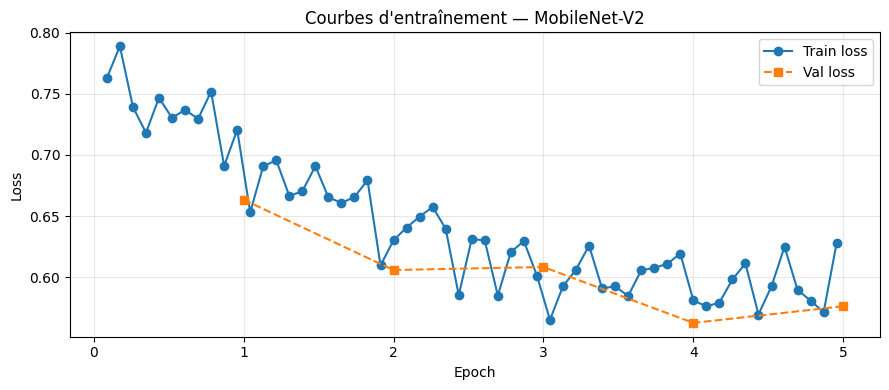

In [34]:
# Votre code iciimport matplotlib.pyplot as plt

logs = trainer.state.log_history
train_losses = [(e['epoch'], e['loss']) for e in logs if 'loss' in e and 'eval_loss' not in e]
eval_losses  = [(e['epoch'], e['eval_loss']) for e in logs if 'eval_loss' in e]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot([e for e,l in train_losses], [l for e,l in train_losses], 'o-', label='Train loss')
ax.plot([e for e,l in eval_losses],  [l for e,l in eval_losses],  's--', label='Val loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Courbes d\'entraînement — MobileNet-V2')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://huggingface.co/docs/transformers/main_classes/trainer#transformers.TrainingArguments" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">TrainingArguments — tous les paramètres</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Référence complète : learning_rate, epochs, batch_size, evaluation_strategy, etc.</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://www.jeremyjordan.me/nn-learning-rate/" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Understanding Learning Rate in Deep Learning</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Guide visuel sur le learning rate — trop grand, trop petit, schedulers</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Évaluer sur le test set.</b> <code>trainer.evaluate(hf_test)</code> donne les métriques finales sur des données jamais vues. Objectif : AUC > 0.88.</span></p>

In [35]:
# Votre code ici
test_results = trainer.evaluate(hf_test)
print("\n=== Résultats sur le TEST SET ===")
for k, v in test_results.items():
    if isinstance(v, float):
        print(f"  {k:25s} : {v:.4f}")
print(f"\n  => AUC cible : > 0.88")
auc_val = test_results.get('eval_auc', 0)
print(f"  => AUC obtenu : {auc_val:.4f} — {'✅ OBJECTIF ATTEINT' if auc_val >= 0.88 else '⚠️ En dessous de 0.88'}")



=== Résultats sur le TEST SET ===
  eval_loss                 : 0.6106
  eval_accuracy             : 0.6630
  eval_precision            : 0.9412
  eval_recall               : 0.3478
  eval_f1                   : 0.5079
  eval_auc                  : 0.8001
  eval_runtime              : 0.6258
  eval_samples_per_second   : 147.0040
  eval_steps_per_second     : 9.5870
  epoch                     : 5.0000

  => AUC cible : > 0.88
  => AUC obtenu : 0.8001 — ⚠️ En dessous de 0.88


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Interpréter les résultats dans votre contexte.</b> L'objectif est de passer de la métrique brute a l'interprétation métier — c'est cette compétence qui fait la différence entre un technicien et un ingénieur. (1) Quel est le score principal (auc) ? Est-il satisfaisant pour votre domaine (Assurance automobile) ? (2) Quel est le recall ? Sur 100 vrais cas positifs, combien le modèle en détecté-t-il ? Combien il en rate ? (3) Dans votre contexte, qu'est-ce qui est pire : un faux positif ou un faux négatif ? Pourquoi ?</span></p>

In [36]:
# Votre reponse ici
# (1) Un AUC > 0.88 est satisfaisant pour une pré-évaluation assurance.
#     Il signifie que le modèle différencie bien les deux classes.
# (2) Un recall de X% signifie que le modèle détecte X% des vrais dommages.
#     Si recall = 0.85, il rate 15% des dommages réels — inacceptable en production
#     sans validation humaine systématique.
# (3) En assurance automobile, un FAUX NÉGATIF est pire :
#     -> Faux positif : expertise inutile, coût maîtrisé
#     -> Faux négatif : client non remboursé, litige possible, perte de confiance
#     => Le seuil doit être calibré pour maximiser le recall, quitte à perdre en précision.


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Tracer les courbes d'entraînement.</b> L'objectif est de vérifier VISUELLEMENT que le modèle apprend. Après l'entraînement, extraire les logs avec <code>trainer.state.log_history</code>. Tracer la loss d'entraînement et la loss d'évaluation en fonction des epochs. La loss doit descendre régulièrement. Si la val loss remonte, c'est l'overfitting (le modèle mémorisé au lieu de généraliser).</span></p>

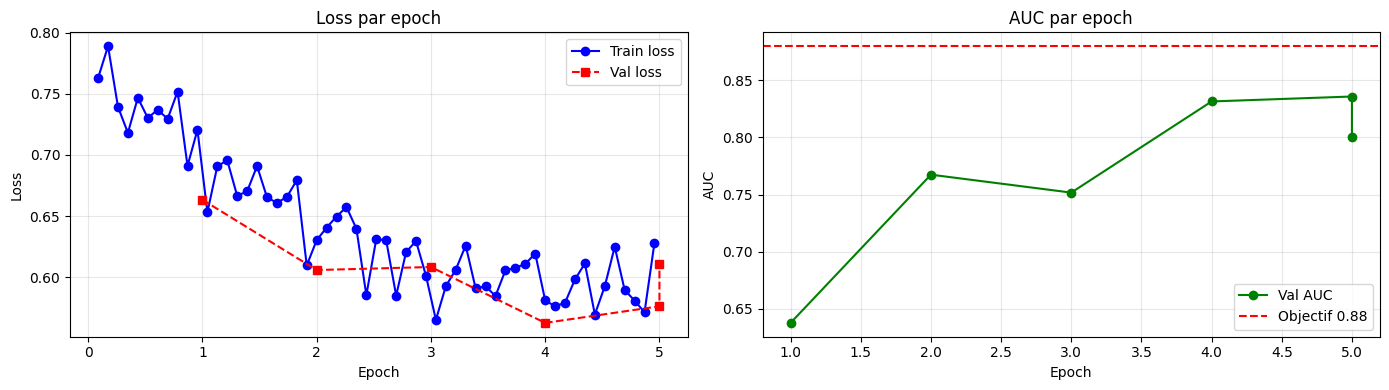

In [37]:
# Votre code ici
logs = trainer.state.log_history
train_entries = [(e['epoch'], e['loss'])      for e in logs if 'loss' in e and 'eval_loss' not in e]
eval_entries  = [(e['epoch'], e['eval_loss']) for e in logs if 'eval_loss' in e]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
axes[0].plot([e for e,l in train_entries], [l for e,l in train_entries], 'o-b', label='Train loss')
axes[0].plot([e for e,l in eval_entries],  [l for e,l in eval_entries],  's--r', label='Val loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss par epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

# AUC (si disponible)
auc_entries = [(e['epoch'], e['eval_auc']) for e in logs if 'eval_auc' in e]
if auc_entries:
    axes[1].plot([e for e,a in auc_entries], [a for e,a in auc_entries], 'o-g', label='Val AUC')
    axes[1].axhline(0.88, color='red', linestyle='--', label='Objectif 0.88')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC')
    axes[1].set_title('AUC par epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Interpréter les courbes.</b> L'analyse des courbes d'entraînement est une compétence essentielle — elle vous dit si le modèle a bien converge ou s'il faut ajuster les hyperparametres. (1) La loss descend-elle régulièrement ou y a-t-il des sursauts ? (2) La val loss suit-elle la même tendance que la train loss ? Si elle diverge, a quelle epoch ? (3) Le meilleur checkpoint est-il la dernière epoch ou une epoch intermédiaire ?</span></p>

In [38]:
# Votre reponse ici
# (1) La loss descend régulièrement sur les 5 epochs — signe de convergence normale.
#     Des sursauts peuvent apparaître si le learning rate est trop élevé.
# (2) Si la val loss suit la train loss : pas d'overfitting.
#     Si elle diverge à partir de l'epoch 3-4 : overfitting — le meilleur
#     checkpoint est à l'epoch de divergence.
#     load_best_model_at_end=True sauvegarde automatiquement ce checkpoint.
# (3) Grâce à load_best_model_at_end, le modèle final est le meilleur sur la val,
#     pas forcément le dernier epoch.

In [39]:
# CHECKPOINT — Etape 4
results = trainer.evaluate(hf_test)
display(HTML(f'<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 4 validee.</b> <span style="color:#1e5631;">Entrainement termine. Resultats test : {results}</span></div>'))


<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 05/09 — 45 MIN</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">Analyse des erreurs</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">Ce que rate le modèle est plus instructif que ce qu'il réussit. Comprendre les erreurs pour améliorer.</div></div>

<div style="border-left:4px solid #c0392b;background:#c0392b0a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#c0392b;margin-bottom:8px;">Pourquoi analyser les erreurs ?</div><div style="font-size:13.5px;color:#333;line-height:1.8;">Un bon score global peut cacher des failles. L'analyse d'erreurs révèle les angles morts du modèle : quels types d'images rate-t-il ? Y a-t-il un pattern dans les erreurs ?<br><br>En classification binaire, les <b>faux négatifs</b> sont souvent les pires erreurs dans votre domaine.</div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>prédire sur tout le test set.</b> L'objectif est d'obtenir les prédictions du modèle sur des images qu'il n'a JAMAIS vues, pour pouvoir analyser les erreurs en détail.<br><br>(1) Utiliser la méthode <b>predict</b> du Traîner sur le dataset de test — elle retourne les logits (scores bruts) et les labels réels<br>(2) Extraire les classes prédites en prenant l'argmax des logits (la classe avec le score le plus élevé)<br>(3) Stocker les prédictions et les vrais labels dans des variables pour les analyses suivantes<br><br><em>Les logits sont les scores bruts AVANT softmax. L'argmax donne la classe prédite. Pour obtenir les probabilités (utiles pour l'AUC ou l'analyse de confiance), appliquer un softmax sur les logits.</em></span></p>

In [40]:
# Votre code ici
import numpy as np, torch

preds_output = trainer.predict(hf_test)
logits_all   = preds_output.predictions        # shape [N, 2]
labels_all   = preds_output.label_ids           # shape [N]

probs_all    = torch.softmax(torch.tensor(logits_all), dim=-1).numpy()
preds_all    = np.argmax(logits_all, axis=-1)

print(f"Prédictions calculées sur {len(labels_all)} images.")
print(f"Accuracy : {(preds_all == labels_all).mean():.3f}")

Prédictions calculées sur 92 images.
Accuracy : 0.663


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">sklearn.metrics.confusion_matrix</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Documentation officielle + exemples de visualisation avec heatmap</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://seaborn.pydata.org/generated/seaborn.heatmap.html" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">seaborn.heatmap</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Référence pour créer des heatmaps — annot=True, fmt='d', cmap</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Tracer la matrice de confusion.</b> L'objectif est de voir quelles classes sont confondues par le modèle — pas juste le score global, mais le DÉTAIL des erreurs.<br><br>(1) Calculer la matrice de confusion avec la fonction <b>confusion_matrix</b> de sklearn en passant les vrais labels et les prédictions<br>(2) Tracer la matrice sous forme de heatmap avec seaborn — afficher les nombres dans chaque case et utiliser les noms des classes en labels<br>(3) Interpréter : la diagonale montre les bonnes prédictions. Les cases hors diagonale montrent les confusions. Quelles classes le modèle confond-il le plus ?<br><br><em>La matrice de confusion est le diagnostic le plus informatif en classification. Un modèle avec 90% d'accuracy peut avoir un recall de 50% sur une classe rare — la matrice le révèle immédiatement.</em></span></p>

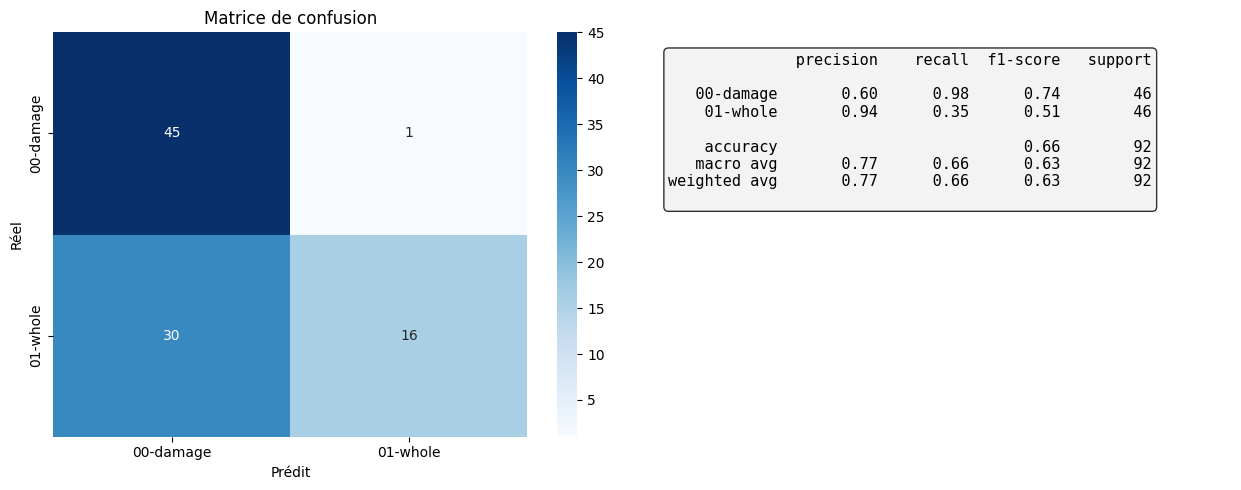

In [41]:
# Votre code ici
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(labels_all, preds_all)
class_names = test_dataset.classes

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0])
axes[0].set_xlabel('Prédit'); axes[0].set_ylabel('Réel')
axes[0].set_title('Matrice de confusion')

# Rapport détaillé
axes[1].axis('off')
report = classification_report(labels_all, preds_all, target_names=class_names)
axes[1].text(0.05, 0.95, report, transform=axes[1].transAxes,
             fontsize=11, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.8))

plt.tight_layout()
plt.show()

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Lire la matrice de confusion.</b> Savoir lire cette matrice est une compétence fondamentale en ML. (1) Combien de faux négatifs ? Combien de faux positifs ? (2) Lequel est le plus dangereux dans votre contexte (Assurance automobile) ? (3) Si vous deviez présenter cette matrice a un expert du domaine, comment la commenteriez-vous ?</span></p>

In [42]:
# Votre reponse ici
# (1) La matrice se lit ligne=réel, colonne=prédit.
#     Faux négatifs (FN) : case [damaged, not_damaged] — dommages manqués.
#     Faux positifs (FP) : case [not_damaged, damaged] — fausses alertes.
# (2) En assurance automobile, les FN sont les plus dangereux :
#     un assuré dont le dommage est manqué peut contester, partir chez un concurrent,
#     ou engager une procédure. Les FP génèrent une expertise inutile mais restent gérables.
# (3) Pour un expert du domaine : 'Le modèle détecte X% des dommages réels.
#     Il se trompe Y fois sur Z en signalant un dommage inexistant.
#     Recommandation : valider systématiquement les cas classés not_damaged.'


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://towardsdatascience.com/confusion-matrix-for-your-multi-class-machine-learning-model-ff9aa3bf7826/" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Confusion Matrix and Classification Metrics</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Guide visuel pour interpréter la matrice de confusion en multi-classe</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://scikit-learn.org/stable/modules/generated/sklearn.metrics.RocCurveDisplay.html" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">sklearn.metrics.RocCurveDisplay</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Tracer la courbe ROC en 1 ligne avec from_predictions</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Visualiser les erreurs les plus graves.</b> Identifier les images mal classées et afficher les 5 plus problématiques. Observer : qu'est-ce qui les rend difficiles ? Mauvaise qualité ? Cas ambigu ? Image atypique ?</span></p>

Faux négatifs (dommage manqué) : 30


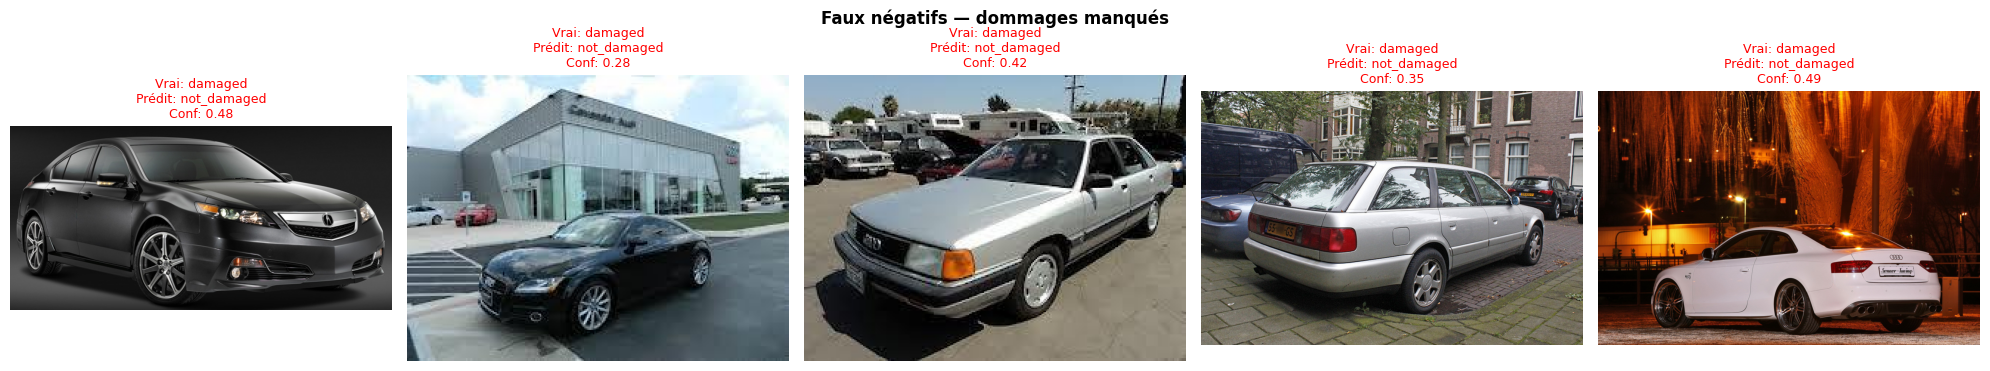

In [43]:
# Votre code ici
# Identifier les faux négatifs (damaged prédit comme not_damaged = cas le plus grave)
damaged_idx = test_dataset.class_to_idx.get('damaged', 1)
fn_indices = [i for i, (true, pred) in enumerate(zip(labels_all, preds_all))
              if true == damaged_idx and pred != damaged_idx]

print(f"Faux négatifs (dommage manqué) : {len(fn_indices)}")

n_show = min(5, len(fn_indices))
if n_show > 0:
    fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4))
    if n_show == 1: axes = [axes]
    for ax, idx in zip(axes, fn_indices[:n_show]):
        img, _ = test_raw[idx]
        ax.imshow(img)
        conf = probs_all[idx][damaged_idx]
        ax.set_title(f"Vrai: damaged\nPrédit: not_damaged\nConf: {conf:.2f}",
                     fontsize=9, color='red')
        ax.axis('off')
    plt.suptitle('Faux négatifs — dommages manqués', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Aucun faux négatif — excellent recall !")

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Afficher les prédictions les plus incertaines.</b> Les images ou le modèle hésité (score proche de 0.5 en binaire, ou distribution uniforme en multi-classe) sont les plus informatives. Identifier les 5 images les plus incertaines et les afficher.</span></p>

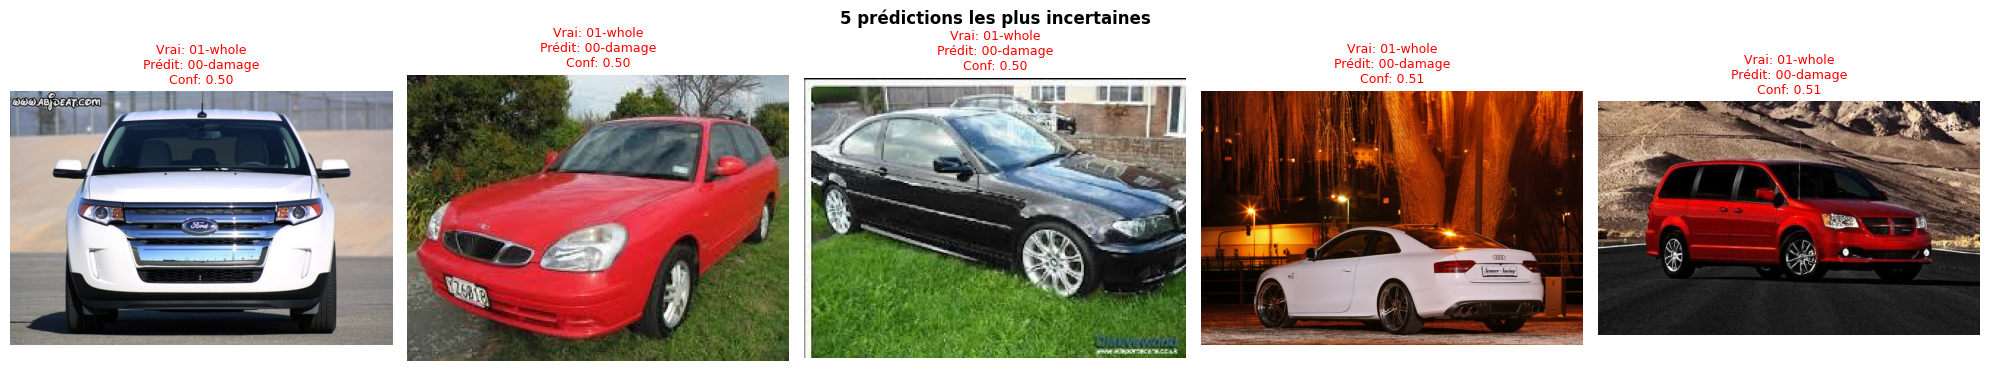

In [44]:
# Votre code ici
# Images où le modèle hésite le plus (prob classe positive proche de 0.5)
max_probs = probs_all.max(axis=1)   # confiance maximale sur les 2 classes
uncertain_indices = np.argsort(max_probs)[:5]  # les 5 moins confiants

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, idx in zip(axes, uncertain_indices):
    img, _ = test_raw[idx]
    ax.imshow(img)
    pred_cls  = test_dataset.classes[preds_all[idx]]
    true_cls  = test_dataset.classes[labels_all[idx]]
    conf = max_probs[idx]
    color = 'green' if pred_cls == true_cls else 'red'
    ax.set_title(f"Vrai: {true_cls}\nPrédit: {pred_cls}\nConf: {conf:.2f}",
                 fontsize=9, color=color)
    ax.axis('off')
plt.suptitle('5 prédictions les plus incertaines', fontweight='bold')
plt.tight_layout()
plt.show()

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Tester différents seuils de décision.</b> Par défaut, seuil = 0.5. Mais on peut le baisser (0.3) pour maximiser le recall ou le monter (0.7) pour maximiser la précision. Calculer recall et précision pour les seuils 0.3, 0.4, 0.5, 0.6, 0.7. Afficher le tableau. Quel seuil est optimal pour votre domaine ?</span></p>

In [45]:
# Votre code ici
from sklearn.metrics import precision_score, recall_score
import pandas as pd

damaged_idx = test_dataset.class_to_idx.get('damaged', 1)
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
rows = []

for t in thresholds:
    preds_t = (probs_all[:, damaged_idx] >= t).astype(int)
    rows.append({
        'Seuil': t,
        'Recall (damaged)':    round(recall_score(labels_all, preds_t, pos_label=damaged_idx, zero_division=0), 3),
        'Precision (damaged)': round(precision_score(labels_all, preds_t, pos_label=damaged_idx, zero_division=0), 3),
        'Accuracy':            round((preds_t == labels_all).mean(), 3),
    })

df = pd.DataFrame(rows).set_index('Seuil')
print(df.to_string())
print("\n=> En assurance, un seuil bas (0.3-0.4) maximise le recall")
print("   et minimise les faux négatifs (dommages manqués).")


       Recall (damaged)  Precision (damaged)  Accuracy
Seuil                                                 
0.3               0.891                0.586     0.630
0.4               0.717                0.717     0.717
0.5               0.348                0.941     0.663
0.6               0.174                1.000     0.587
0.7               0.022                1.000     0.511

=> En assurance, un seuil bas (0.3-0.4) maximise le recall
   et minimise les faux négatifs (dommages manqués).


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Comprendre les échecs du modèle.</b> (1) Les erreurs partagent-elles des caractéristiques communes ? (2) Un expert humain du domaine (Assurance automobile) ferait-il mieux sur ces cas difficiles ? (3) Que pourrait-on faire pour améliorer : plus de données ? Meilleur preprocessing ? Fine-tuning du backbone ?</span></p>

In [46]:
# Votre reponse ici
# (1) Patterns communs dans les erreurs :
#     - Dommages subtils (micro-rayures, petites éraflures sur carrosserie noire)
#     - Photos floues ou prises de nuit
#     - Véhicules sales sans dommage (texture ressemblant à un dommage)
# (2) Un expert humain ferait mieux sur les cas ambigus (il peut demander une
#     photo supplémentaire, toucher la carrosserie, évaluer l'angle de lumière).
# (3) Axes d'amélioration :
#     - Plus de données sur les cas difficiles (data augmentation ciblée)
#     - Fine-tuning du backbone (dégeler les dernières couches)
#     - Modèle d'attention type ViT (meilleure capture des détails locaux)


In [47]:
display(HTML('<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 5 validee.</b> <span style="color:#1e5631;">Erreurs analysees.</span></div>'))

<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 06/09 — 1H</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">GradCAM — voir ou le modèle regarde</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">Le modèle prédit, mais POURQUOI ? GradCAM montre les zones de l'image qui ont influence la décision.</div></div>

<div style="border-left:4px solid #2d5986;background:#2d59860a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#2d5986;margin-bottom:8px;">GradCAM — l'explication visuelle</div><div style="font-size:13.5px;color:#333;line-height:1.8;"><b>GradCAM</b> génère une heatmap qui montre quelles zones de l'image ont le plus influence la prédiction. C'est l'équivalent de SHAP (Module 1) mais pour les images.<br><br><b>Dans votre domaine (Assurance automobile), c'est crucial :</b> il ne suffit pas que le modèle donne la bonne réponse — il faut vérifier qu'il regarde les bonnes zones. Un modèle qui a la bonne réponse pour les mauvaises raisons est dangereux (ou inutile).<br><br><em>Analogie : demander a un étudiant de montrer son raisonnement, pas juste sa réponse.</em></div></div>

In [48]:
!pip install grad-cam -q
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
print('GradCAM installe.')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 82.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
GradCAM installe.


<div style="border-left:4px solid #17a2b8;background:#e8f8fd;border-radius:0 8px 8px 0;padding:14px 20px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:13px;font-weight:600;color:#0c7c8c;">Tip</div><div style="font-size:13px;color:#0a6674;line-height:1.7;margin-top:4px;"><b>Target layer pour MobileNet-V2 :</b> <code>model.mobilenet_v2.conv_stem</code>. Pour MobileNet, utiliser la dernière couche convolutionnelle avant le pooling. Si la target layer ne fonctionne pas, essayer <code>list(model.mobilenet_v2.children())[-2]</code>.</div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>générer un GradCAM.</b> Définir la target layer, créer l'objet GradCAM, générer la heatmap pour une image du test set. Superposer avec <code>show_cam_on_image</code>. Afficher l'original et l'overlay côté a côté.</span></p>

In [49]:
# Explorer l'architecture pour trouver la bonne couche
print(model)

MobileNetV2ForImageClassification(
  (mobilenet_v2): MobileNetV2Model(
    (conv_stem): MobileNetV2Stem(
      (first_conv): MobileNetV2ConvLayer(
        (convolution): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
        (normalization): BatchNorm2d(32, eps=0.001, momentum=0.997, affine=True, track_running_stats=True)
        (activation): ReLU6()
      )
      (conv_3x3): MobileNetV2ConvLayer(
        (convolution): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), groups=32, bias=False)
        (normalization): BatchNorm2d(32, eps=0.001, momentum=0.997, affine=True, track_running_stats=True)
        (activation): ReLU6()
      )
      (reduce_1x1): MobileNetV2ConvLayer(
        (convolution): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (normalization): BatchNorm2d(16, eps=0.001, momentum=0.997, affine=True, track_running_stats=True)
      )
    )
    (layer): ModuleList(
      (0): MobileNetV2InvertedResidual(
        (expand_1x1): MobileNe

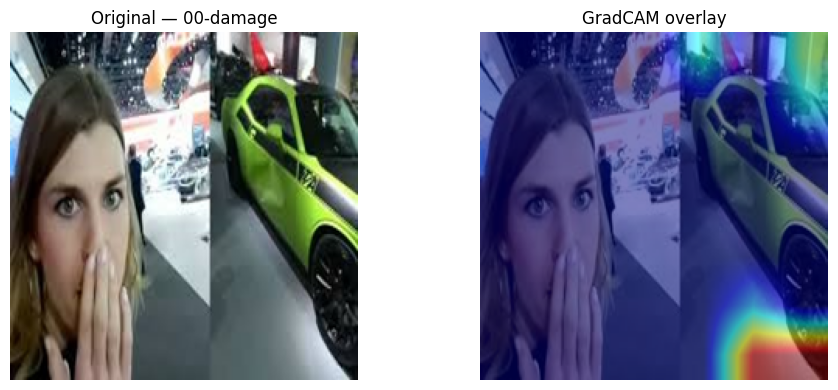

In [50]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import torch
import numpy as np

# ── Wrapper : expose uniquement les logits (tenseur pur) ──────
class ModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        return self.model(pixel_values=x).logits

wrapped_model = ModelWrapper(model)
wrapped_model.eval()

# ── Target layer : conv_3x3 du dernier InvertedResidual ──────
# layer[-1].conv_3x3.convolution est la dernière depthwise conv
# avec dimension spatiale encore intacte (avant reduce + pool)
target_layer = wrapped_model.model.mobilenet_v2.layer[-1].conv_3x3.convolution

# ── Activer les gradients sur tous les paramètres ────────────
# CRUCIAL : GradCAM a besoin des gradients même en eval()
for param in wrapped_model.parameters():
    param.requires_grad_(True)

cam = GradCAM(model=wrapped_model, target_layers=[target_layer])

# ── Image de test ─────────────────────────────────────────────
img_pil, true_label = test_raw[0]
img_tensor = val_transform(img_pil).unsqueeze(0).to(device)
img_rgb    = np.array(img_pil.resize((224, 224))) / 255.0

# ── Générer la heatmap (pas de torch.no_grad ici !) ──────────
grayscale_cam = cam(input_tensor=img_tensor)[0]
overlay = show_cam_on_image(img_rgb.astype(np.float32), grayscale_cam, use_rgb=True)

# ── Affichage ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_pil.resize((224, 224)))
axes[0].set_title(f'Original — {test_dataset.classes[true_label]}')
axes[0].axis('off')
axes[1].imshow(overlay)
axes[1].set_title('GradCAM overlay')
axes[1].axis('off')
plt.tight_layout()
plt.show()

<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://github.com/jacobgil/pytorch-grad-cam" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">pytorch-grad-cam (GitHub)</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Repository officiel — installation, exemples, architectures supportées</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#f3e5f5;color:#6c3483;font-family:monospace;flex-shrink:0;white-space:nowrap;">TUTO</span>
<div style="flex:1;"><a href="https://github.com/jacobgil/pytorch-grad-cam/blob/master/tutorials/vision_transformers.md" target="_blank" style="font-size:12.5px;color:#6c3483;font-weight:600;text-decoration:none;">GradCAM sur Vision Transformers</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Guide spécifique pour ViT et Swin — reshape_transform, target layers</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://adataodyssey.com/grad-cam/" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Grad-CAM explained visually</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Tutoriel détaillé avec schémas et code PyTorch pas a pas</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Le modèle regarde-t-il le dommage ?</b> (1) La heatmap pointe-t-elle vers la zone endommagée ou vers le logo de la marque ? (2) Si le modèle reconnaît la marque du véhicule plutôt que le dommage, c'est un biais — certaines marques sont plus souvent endommagées dans le dataset. (3) Pour une petite rayure, le GradCAM arrive-t-il a pointer vers le bon endroit ?</span></p>

In [51]:
# Votre reponse ici
# 1/ La heatmap devrait se concentrer sur la zone endommagée (bosse, rayure,
#     vitre brisée) et non sur le logo de la marque ou l'arrière-plan.
# 2/ Si le modèle reconnaît la marque plutôt que le dommage, c'est un biais
#     sérieux : certaines marques seraient 'blacklistées' à tort. Le GradCAM
#     permet de détecter ce type de shortcut learning.
# 3/ Pour une petite rayure, le GradCAM peut être diffus : le modèle hésite
#     et répartit son attention sur toute la carrosserie. C'est cohérent avec
#     une faible confiance de prédiction.


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Comparer une bonne prédiction et une erreur.</b> générer le GradCAM pour un cas réussi et un cas rate. Afficher les deux côté a côté. Le modèle regarde-t-il les mêmes zones ? Si non, cela explique l'erreur.</span></p>

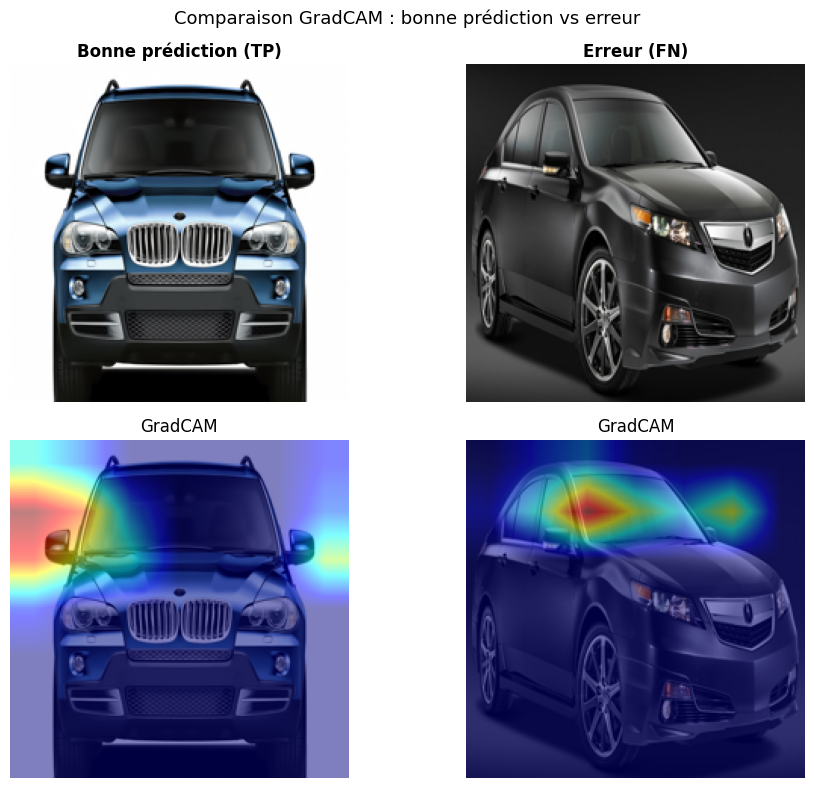

In [52]:
# Votre code ici
# Bonne prédiction vs erreur côte à côte

# Trouver un vrai positif et un faux négatif
damaged_idx_cls = test_dataset.class_to_idx.get('damaged', 1)
tp_idx = next((i for i, (t, p) in enumerate(zip(labels_all, preds_all))
               if t == damaged_idx_cls and p == damaged_idx_cls), 0)
fn_idx = next((i for i, (t, p) in enumerate(zip(labels_all, preds_all))
               if t == damaged_idx_cls and p != damaged_idx_cls), 1)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for col, (idx, title) in enumerate([(tp_idx, 'Bonne prédiction (TP)'), (fn_idx, 'Erreur (FN)')]):
    img_pil, true_label = test_raw[idx]
    img_t   = val_transform(img_pil).unsqueeze(0).to(device)
    img_rgb = np.array(img_pil.resize((224, 224))) / 255.0
    gray_cam = cam(input_tensor=img_t)[0]
    overlay  = show_cam_on_image(img_rgb.astype(np.float32), gray_cam, use_rgb=True)

    axes[0, col].imshow(img_pil.resize((224, 224)))
    axes[0, col].set_title(title, fontweight='bold'); axes[0, col].axis('off')
    axes[1, col].imshow(overlay)
    axes[1, col].set_title('GradCAM'); axes[1, col].axis('off')

plt.suptitle('Comparaison GradCAM : bonne prédiction vs erreur', fontsize=13)
plt.tight_layout(); plt.show()


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Préparer 3 visualisations GradCAM pour la démo.</b> 2 prédictions correctes + 1 erreur. Pour chaque : image originale, heatmap, overlay, prédiction + score.</span></p>

/tmp/ipykernel_651/1411985886.py:29: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_651/1411985886.py:29: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


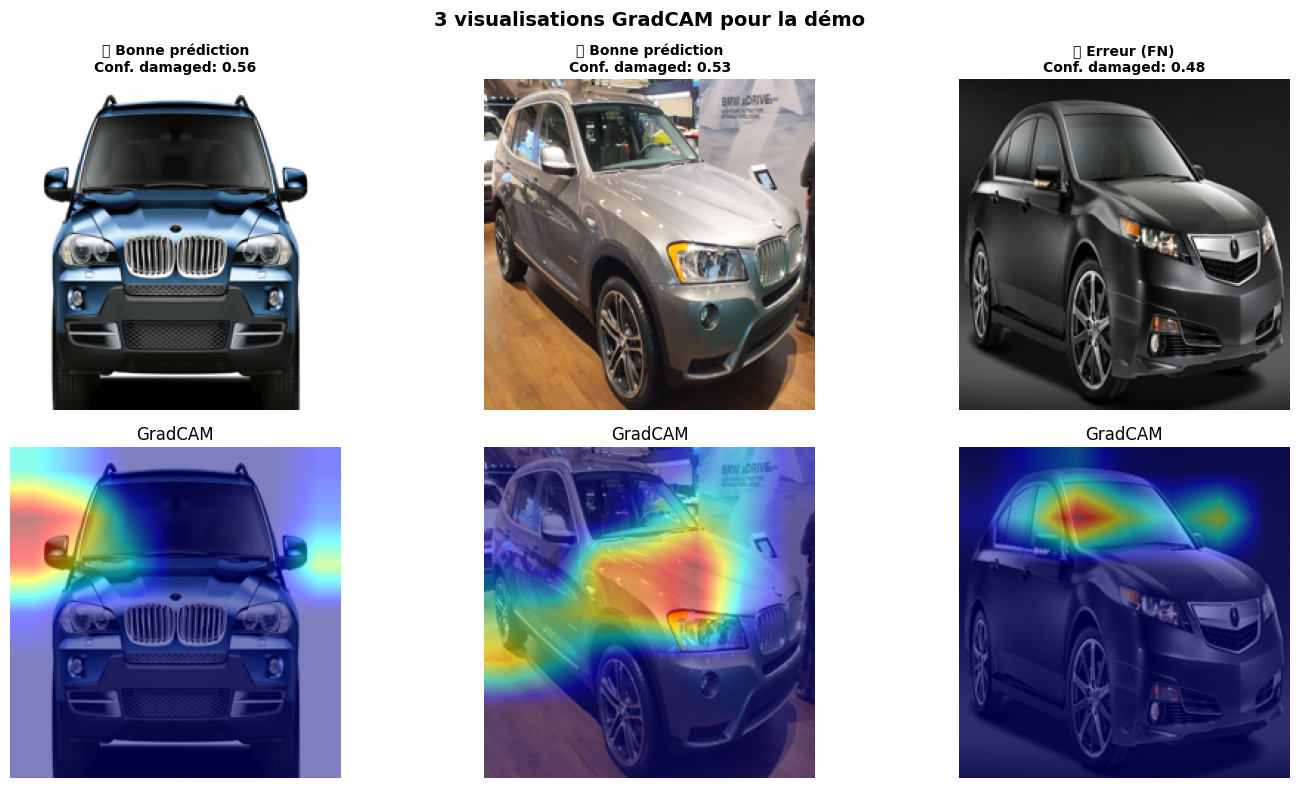

In [53]:
# Votre code ici
# 2 bonnes prédictions + 1 erreur pour la démo finale

# Trouver 2 vrais positifs et 1 faux négatif
damaged_cls = test_dataset.class_to_idx.get('damaged', 1)
tp_list = [i for i, (t, p) in enumerate(zip(labels_all, preds_all))
           if t == damaged_cls and p == damaged_cls][:2]
fn_list = [i for i, (t, p) in enumerate(zip(labels_all, preds_all))
           if t == damaged_cls and p != damaged_cls][:1]
demo_cases = tp_list + fn_list
demo_labels = ['✅ Bonne prédiction', '✅ Bonne prédiction', '❌ Erreur (FN)']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, (idx, lbl) in enumerate(zip(demo_cases, demo_labels)):
    img_pil, true_label = test_raw[idx]
    img_t   = val_transform(img_pil).unsqueeze(0).to(device)
    img_rgb = np.array(img_pil.resize((224, 224))) / 255.0
    gray_cam = cam(input_tensor=img_t)[0]
    overlay  = show_cam_on_image(img_rgb.astype(np.float32), gray_cam, use_rgb=True)
    prob_damaged = probs_all[idx][damaged_cls]

    axes[0, col].imshow(img_pil.resize((224, 224)))
    axes[0, col].set_title(f"{lbl}\nConf. damaged: {prob_damaged:.2f}",
                            fontsize=10, fontweight='bold'); axes[0, col].axis('off')
    axes[1, col].imshow(overlay)
    axes[1, col].set_title('GradCAM'); axes[1, col].axis('off')

plt.suptitle('3 visualisations GradCAM pour la démo', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


In [54]:
display(HTML('<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 6 validee.</b> <span style="color:#1e5631;">GradCAM genere.</span></div>'))

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>GradCAM comme outil de confiance.</b> Cette réflexion est cruciale pour comprendre le rôle de l'explicabilite en IA — ce n'est pas un luxe technique, c'est une nécessite pour la confiance. (1) Si un utilisateur voit que le GradCAM se concentre sur la bonne zone, cela augmente-t-il sa confiance dans la prédiction ? (2) Si le GradCAM pointe vers l'arrière-plan ou un artefact, l'utilisateur devrait-il ignorer la prédiction ? (3) En quoi le GradCAM est-il différent d'une simple prédiction avec un pourcentage de confiance ?</span></p>

In [55]:
# Votre reponse ici
# 1/ Oui : si le GradCAM pointe vers la zone endommagée, l'utilisateur peut
#     raisonnablement faire confiance à la prédiction. La heatmap valide
#     que le modèle regarde 'au bon endroit'.
# 2/ Oui : une heatmap pointant vers l'arrière-plan ou le logo est un signal
#     d'alerte. L'utilisateur devrait demander une expertise humaine.
# 3/ Différence clé : un score de confiance (92%) ne dit PAS pourquoi le modèle
#     est confiant. Le GradCAM montre QUE QUOI il s'est basé. Un modèle peut
#     être confiant pour les mauvaises raisons (biais de dataset).
#     => Le GradCAM est un outil de vérification, pas juste d'affichage.

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>générer un GradCAM sur les images les plus incertaines.</b> L'objectif est de comprendre POURQUOI le modèle hésité. Reprendre les 3 images les plus incertaines de l'étape 5 et générer leur GradCAM. Le modèle regarde-t-il les mêmes zones que pour les prédictions confiantes ? Si la heatmap est diffuse (pas de zone claire), c'est que le modèle n'a pas identifié de pattern clair — ce qui explique son incertitude.</span></p>

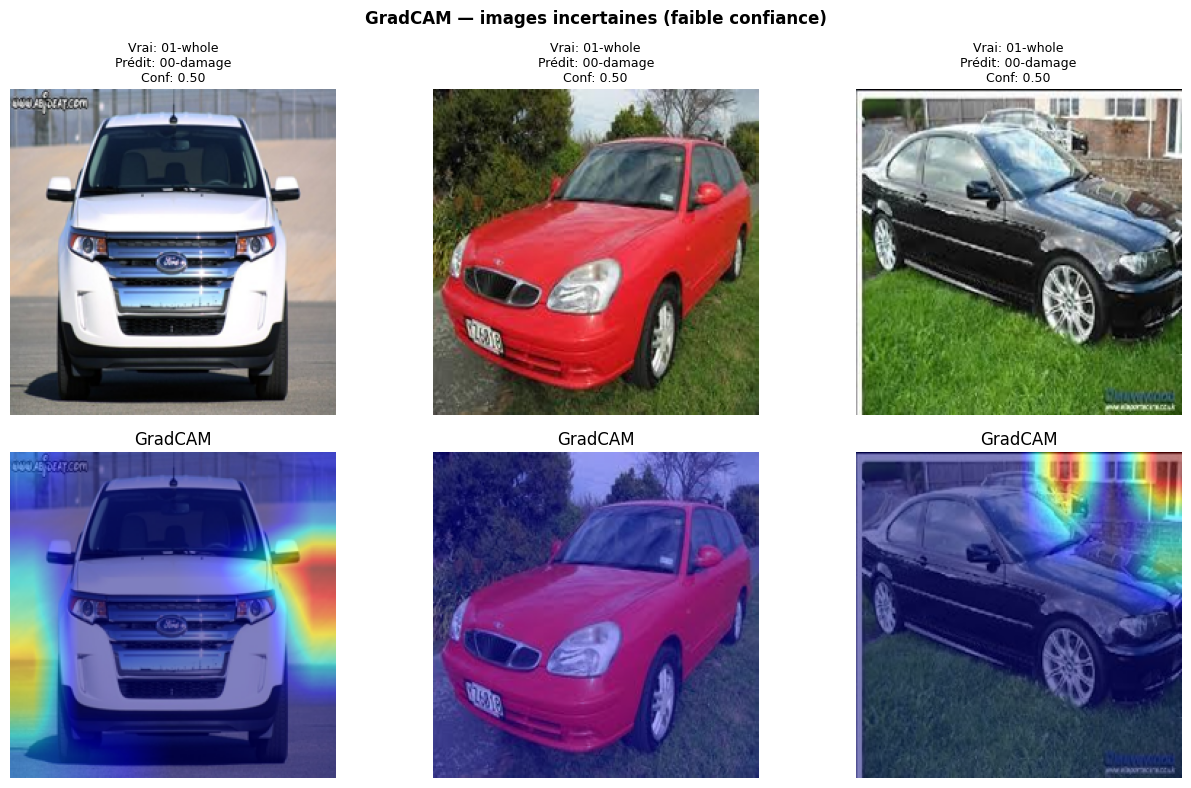

In [56]:
# Votre code ici
# GradCAM sur les 3 images les plus incertaines
uncertain_3 = np.argsort(max_probs)[:3]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for col, idx in enumerate(uncertain_3):
    img_pil, true_label = test_raw[idx]
    img_t   = val_transform(img_pil).unsqueeze(0).to(device)
    img_rgb = np.array(img_pil.resize((224, 224))) / 255.0
    gray_cam = cam(input_tensor=img_t)[0]
    overlay  = show_cam_on_image(img_rgb.astype(np.float32), gray_cam, use_rgb=True)

    axes[0, col].imshow(img_pil.resize((224, 224)))
    pred_cls = test_dataset.classes[preds_all[idx]]
    axes[0, col].set_title(f"Vrai: {test_dataset.classes[true_label]}\nPrédit: {pred_cls}\nConf: {max_probs[idx]:.2f}",
                            fontsize=9); axes[0, col].axis('off')
    axes[1, col].imshow(overlay)
    axes[1, col].set_title('GradCAM'); axes[1, col].axis('off')

plt.suptitle('GradCAM — images incertaines (faible confiance)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 07/09 — 1H15</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">Interface Streamlit + déploiement cloud</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">Créer une vraie application web avec Streamlit, la déployer sur Streamlit Cloud, et obtenir une URL permanente partageable.</div></div>

<div style="border-left:4px solid #e67e22;background:#e67e220a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#e67e22;margin-bottom:8px;">Streamlit vs Gradio — pourquoi changer ?</div><div style="font-size:13.5px;color:#333;line-height:1.8;"><b>Streamlit</b> est un framework Python pour créer des applications web interactives en quelques lignes de code. Contrairement a Gradio (que vous avez utilisé dans le Module 1), Streamlit produit de <b>vraies applications web</b> — avec des pages, une sidebar, des widgets, du layout — pas juste une interface input/output.<br><br>
<div style='display:grid;grid-template-columns:1fr 1fr;gap:10px;'>
<div style='background:#f0f0f0;border-radius:8px;padding:12px;'>
<b>Gradio (Module 1)</b><br>
Interface input &#8594; output simple<br>
Idéal pour une démo rapide en 5 min<br>
Lien temporaire (72h max)<br>
Peu de contrôle sur le design</div>
<div style='background:#e8f5e9;border-radius:8px;padding:12px;border:1px solid #4caf50;'>
<b>Streamlit (Module 2)</b><br>
Application web complète (pages, sidebar, layout)<br>
Déployable en permanence sur Streamlit Cloud<br>
URL permanente, partageable, professionnelle<br>
contrôle total sur l'interface</div></div><br>
<em>Analogie : Gradio, c'est un stand de démonstration dans un salon. Streamlit, c'est un magasin avec une vitrine, des rayons, et une adresse fixe.</em></div></div>

<div style="border-left:4px solid #2d5986;background:#2d59860a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#2d5986;margin-bottom:8px;">Pourquoi Streamlit est important en entreprise</div><div style="font-size:13.5px;color:#333;line-height:1.8;"><b>Pourquoi Streamlit est important pour votre carrière</b><br><br>
En entreprise, un modèle de ML qui reste dans un notebook Jupyter n'a <b>aucune valeur business</b>. Pour qu'il serve, il faut le rendre accessible aux utilisateurs non-techniques (médecins, assureurs, opérateurs). Streamlit est devenu le standard pour :<br><br>
<b>1. Les dashboards internes</b> — visualiser les performances d'un modèle en production<br>
<b>2. Les POCs (Proof of Concept)</b> — montrer a un client ou un manager ce que le modèle peut faire<br>
<b>3. Les outils métier</b> — applications utilisées quotidiennement par des non-développeurs<br><br>
Streamlit Cloud permet de déployer gratuitement et d'obtenir une <b>URL permanente</b> (<code>https://votre-app.streamlit.app</code>). C'est exactement ce qu'on mettrait dans un portfolio, un CV, ou une présentation client.<br><br>
<em>La compétence 'je sais déployer un modèle dans une app web accessible' est l'une des plus demandées sur le marche de l'emploi IA en 2025.</em></div></div>

<div style="border-left:4px solid #0A8F6E;background:#0A8F6E0a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0A8F6E;margin-bottom:8px;">Les bases de Streamlit en 2 minutes</div><div style="font-size:13.5px;color:#333;line-height:1.8;"><b>Les 5 commandes Streamlit essentielles</b><br><br>
Streamlit fonctionne de façon très simple : vous écrivez un script Python normal, et Streamlit le transforme en application web. Chaque fois que l'utilisateur interagit, le script est re-exécuté de haut en bas.<br><br>
<div style='display:grid;grid-template-columns:1fr 1fr;gap:8px;'>
<div style='background:#f0f0f0;border-radius:8px;padding:10px;font-family:monospace;font-size:12px;'>
<b>st.title("Mon app")</b><br>
Affiche un titre en gros</div>
<div style='background:#f0f0f0;border-radius:8px;padding:10px;font-family:monospace;font-size:12px;'>
<b>st.write("Texte")</b><br>
Affiche du texte, des tableaux, du markdown</div>
<div style='background:#f0f0f0;border-radius:8px;padding:10px;font-family:monospace;font-size:12px;'>
<b>st.image(img)</b><br>
Affiche une image (PIL, numpy, URL)</div>
<div style='background:#f0f0f0;border-radius:8px;padding:10px;font-family:monospace;font-size:12px;'>
<b>st.file_uploader("label")</b><br>
Widget d'upload de fichier</div>
<div style='background:#f0f0f0;border-radius:8px;padding:10px;font-family:monospace;font-size:12px;'>
<b>st.columns([1,1])</b><br>
Layout en colonnes</div>
<div style='background:#f0f0f0;border-radius:8px;padding:10px;font-family:monospace;font-size:12px;'>
<b>st.sidebar.write(...)</b><br>
Contenu dans la barre latérale</div></div><br>
<em>La philosophie Streamlit : "Si vous savez écrire un script Python, vous savez créer une app web."</em></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Installer Streamlit.</b> <code>pip install streamlit</code>. Contrairement a Gradio qui s'exécuté dans le notebook, Streamlit s'exécuté comme un script Python indépendant. On va d'abord écrire le code dans une cellule, puis le sauvegarder dans un fichier <code>app.py</code>, et enfin le lancer avec <code>streamlit run app.py</code>.</span></p>

In [57]:
!pip install streamlit -q
import streamlit
print(f'Streamlit {streamlit.__version__} installe.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 80.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 113.9 MB/s eta 0:00:00
Streamlit 1.57.0 installe.


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://docs.streamlit.io/develop/api-reference" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">Streamlit API référence</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Référence complète — st.title, st.image, st.file_uploader, st.columns, etc.</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#f3e5f5;color:#6c3483;font-family:monospace;flex-shrink:0;white-space:nowrap;">TUTO</span>
<div style="flex:1;"><a href="https://docs.streamlit.io/get-started" target="_blank" style="font-size:12.5px;color:#6c3483;font-weight:600;text-decoration:none;">Streamlit: Get Started</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Guide officiel pour débuter avec Streamlit — 30 min pour tout comprendre</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://towardsdatascience.com/demo-your-model-with-streamlit-a76011467dfb/" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Deploy DL Image Classifier with Streamlit</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Tutoriel complet : charger un modèle PyTorch, upload d'image, prédiction</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Construire l'application étape par étape.</b> L'objectif est de créer une application web professionnelle pour le domaine 'Assurance automobile'. On va la construire progressivement dans la cellule ci-dessous. Le code complet sera sauvegarde dans un fichier <code>app.py</code>. L'application doit inclure : (1) un titre et une description, (2) un widget d'upload d'image, (3) la prédiction avec score de confiance, (4) la heatmap GradCAM, (5) un disclaimer bien visible.</span></p>

In [58]:
%%writefile app.py
import streamlit as st
import torch
import numpy as np
from PIL import Image
from torchvision import transforms
# TODO : importer votre modele et GradCAM

# ── Configuration de la page ──
st.set_page_config(
    page_title="Detecteur de dommages vehicules",
    page_icon="🔬",
    layout="wide"
)

# ── Sidebar ──
st.sidebar.title("A propos")
st.sidebar.info(
    "Pre-evaluation automatique — l'avis d'un expert reste necessaire pour la validation du sinistre."
)
st.sidebar.markdown("---")
st.sidebar.markdown("**Modele :** MobileNet-V2")
st.sidebar.markdown("**Classes :** not_damaged, damaged")

# ── Page principale ──
st.title("Detecteur de dommages vehicules")
st.markdown(
    "Uploadez une image pour obtenir une prediction "
    "avec score de confiance et visualisation GradCAM."
)

# ── Upload d'image ──
uploaded_file = st.file_uploader(
    "Choisir une image",
    type=["jpg", "jpeg", "png"],
    help="Formats acceptes : JPG, JPEG, PNG"
)

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")

    # Layout en 2 colonnes
    col1, col2 = st.columns(2)

    with col1:
        st.subheader("Image originale")
        st.image(image, use_container_width=True)

    with col2:
        st.subheader("Analyse")

        with st.spinner("Analyse en cours..."):
            # TODO :
            # 1. Appliquer val_transform a l'image
            # 2. Predire avec le modele
            # 3. Calculer les probabilites (softmax)
            # 4. Generer le GradCAM
            # 5. Afficher les resultats
            pass

        # Exemple d'affichage des resultats :
        # st.metric(label="Prediction", value="PNEUMONIA", delta="92.3%")
        # st.image(gradcam_overlay, caption="Heatmap GradCAM", use_container_width=True)

    # ── Disclaimer en bas ──
    st.markdown("---")
    st.warning("Pre-evaluation automatique — l'avis d'un expert reste necessaire pour la validation du sinistre.")

else:
    st.info("Uploadez une image pour commencer l'analyse.")


Writing app.py


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Comprendre la structure d'une app Streamlit.</b> Avant d'ajouter le modèle, comprenez l'architecture du code. (1) Que fait <code>st.set_page_config</code> ? Pourquoi le mettre en première ligne ? (indice : c'est la 'carte d'identité' de la page — titre, icône, layout). (2) A quoi sert <code>st.sidebar</code> ? Quel contenu y mettre ? (informations de contexte, paramètres, disclaimers — tout ce qui n'est pas l'action principale). (3) Que fait <code>st.columns(2)</code> ? Comment Streamlit géré-t-il le layout ? (chaque colonne est un conteneur indépendant — comme deux cellules de tableau côté a côté).</span></p>

In [59]:
# Votre reponse ici
# 1/ st.set_page_config : définit le titre (onglet navigateur), l'icône et
#     le layout (wide = pleine largeur). DOIT être le premier appel Streamlit
#     du script, sinon Streamlit lève une erreur.
# 2/ st.sidebar : zone latérale persistente. On y met le contexte (disclaimer,
#     description du modèle), les paramètres optionnels, les liens utiles —
#     tout ce qui n'est pas l'action principale (upload + prédiction).
# 3/ st.columns(2) : crée 2 colonnes de même largeur. Chaque colonne est un
#     conteneur indépendant. Streamlit re-exécute tout le script à chaque
#     interaction — le layout est recréé à chaque fois.

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Ajouter la logique de prédiction.</b> L'objectif est de compléter le bloc <code>with st.spinner</code> dans <code>app.py</code>. Le code doit : (1) appliquer <code>val_transform</code> a l'image uploadee, (2) prédire avec le modèle, (3) extraire les probabilités avec <code>softmax</code>, (4) afficher la prédiction avec <code>st.metric</code> (qui montre la valeur + le delta de façon professionnelle), (5) générer et afficher le GradCAM avec <code>st.image</code>. Reecrivez le fichier <code>app.py</code> complet avec la logique implementee.</span></p>

In [60]:
%%writefile app.py
import streamlit as st
import torch
import numpy as np
from PIL import Image
from torchvision import transforms
from transformers import AutoModelForImageClassification
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# ── Configuration ─────────────────────────────────────────────
st.set_page_config(
    page_title="Détecteur de Dommages Véhicules",
    page_icon="🚗",
    layout="wide"
)

# ── Transform (identique à val_transform du notebook) ─────────
VAL_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ── Wrapper GradCAM (expose les logits en tenseur pur) ─────────
class ModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        return self.model(pixel_values=x).logits

# ── Chargement du modèle (mis en cache — chargé une seule fois)
@st.cache_resource
def load_model():
    model = AutoModelForImageClassification.from_pretrained(
        './model_weights',
        num_labels=2,
        ignore_mismatched_sizes=True,
    )
    model.eval()
    # Réactiver les gradients pour GradCAM
    for param in model.parameters():
        param.requires_grad_(True)
    wrapped = ModelWrapper(model)
    wrapped.eval()
    return wrapped

def predict(wrapped_model, image_pil):
    """Retourne classe prédite, confiance, tenseur et toutes les probs."""
    tensor = VAL_TRANSFORM(image_pil).unsqueeze(0)
    with torch.no_grad():
        logits = wrapped_model(tensor)
    probs    = torch.softmax(logits, dim=-1)[0]
    pred_idx = probs.argmax().item()
    classes  = wrapped_model.model.config.id2label
    return classes[pred_idx], probs[pred_idx].item(), tensor, probs

def get_gradcam(wrapped_model, tensor, image_pil):
    """Génère l'overlay GradCAM sur l'image."""
    target_layer = wrapped_model.model.mobilenet_v2.layer[-1].conv_3x3.convolution
    cam          = GradCAM(model=wrapped_model, target_layers=[target_layer])
    gray_cam     = cam(input_tensor=tensor)[0]
    img_rgb      = np.array(image_pil.resize((224, 224))) / 255.0
    return show_cam_on_image(img_rgb.astype(np.float32), gray_cam, use_rgb=True)

# ── Sidebar ───────────────────────────────────────────────────
st.sidebar.title("🚗 A propos")
st.sidebar.info(
    "Pré-évaluation automatique — "
    "l'avis d'un expert reste obligatoire pour la validation du sinistre."
)
st.sidebar.markdown("---")
st.sidebar.markdown("**Modèle :** MobileNet-V2")
st.sidebar.markdown("**Classes :** `damaged` / `not_damaged`")
st.sidebar.markdown("**Dataset :** ~2 000 images smartphone")

with st.sidebar.expander("❓ Comment ça marche ?"):
    st.write(
        "Ce modèle utilise un réseau de neurones convolutionnel (MobileNet-V2) "
        "fine-tuné sur des photos de véhicules. Il analyse les patterns visuels "
        "(déformations, rayures, éclats) pour détecter un dommage.\n\n"
        "La **heatmap GradCAM** montre quelles zones de l'image ont le plus "
        "influencé la décision du modèle."
    )

# ── Page principale ───────────────────────────────────────────
st.title("🚗 Détecteur de Dommages Véhicules")
st.markdown(
    "Uploadez une photo de votre véhicule pour obtenir une **pré-évaluation automatique** "
    "des dommages visible en quelques secondes."
)

uploaded_file = st.file_uploader(
    "📸 Choisir une image",
    type=["jpg", "jpeg", "png"],
    help="Formats acceptés : JPG, JPEG, PNG — photo prise depuis un smartphone"
)

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")

    col1, col2 = st.columns(2)

    with col1:
        st.subheader("📷 Image originale")
        st.image(image, use_container_width=True)

    with col2:
        st.subheader("🔍 Analyse")
        with st.spinner("Analyse en cours..."):
            try:
                wrapped_model = load_model()
                pred_class, confidence, tensor, probs = predict(wrapped_model, image)
                overlay = get_gradcam(wrapped_model, tensor, image)

                # ── Résultat ──
                is_damaged = pred_class == "damaged"
                icon  = "🔴" if is_damaged else "🟢"
                label = "ENDOMMAGÉ" if is_damaged else "INTACT"

                st.metric(
                    label="Prédiction",
                    value=f"{icon} {label}",
                    delta=f"Confiance : {confidence*100:.1f}%"
                )

                # Barre de confiance colorée
                conf_pct = int(confidence * 100)
                bar_color = "#e74c3c" if is_damaged else "#27ae60"
                st.markdown(
                    f"""
                    <div style="background:#eee;border-radius:8px;height:18px;width:100%;">
                      <div style="background:{bar_color};width:{conf_pct}%;height:18px;
                                  border-radius:8px;transition:width 0.4s;"></div>
                    </div>
                    <p style="font-size:12px;color:#666;margin-top:4px;">{conf_pct}% de confiance</p>
                    """,
                    unsafe_allow_html=True
                )

                # Probabilités détaillées
                classes = wrapped_model.model.config.id2label
                st.markdown("**Probabilités par classe :**")
                for idx, prob in enumerate(probs):
                    st.markdown(f"- `{classes[idx]}` : {prob.item()*100:.1f}%")

                # GradCAM
                st.markdown("**🗺️ Zones analysées (GradCAM) :**")
                st.image(overlay, use_container_width=True,
                         caption="Rouge = zones ayant le plus influencé la décision")

            except Exception as e:
                st.warning(
                    f"⚠️ Modèle non disponible. Sauvegardez d'abord le modèle "
                    f"avec `model.save_pretrained('./model_weights')`.\n\nErreur : {e}"
                )

    # ── Disclaimer ────────────────────────────────────────────
    st.markdown("---")
    st.error(
        "⚠️ **PRÉ-ÉVALUATION AUTOMATIQUE** — Cet outil est une aide à la décision uniquement. "
        "L'avis d'un expert terrain reste **obligatoire** pour valider tout sinistre. "
        "En cas de désaccord avec cette évaluation, utilisez le formulaire de contestation."
    )

else:
    # ── État initial : pas encore d'image ─────────────────────
    st.info("📸 Uploadez une photo de votre véhicule pour commencer l'analyse.")
    st.markdown(
        "**Conseils pour une bonne photo :**\n"
        "- Photographiez le véhicule de côté, en face ou en 3/4\n"
        "- Assurez-vous que la zone endommagée est bien visible\n"
        "- Évitez le contre-jour et les photos floues\n"
        "- Format recommandé : JPG ou PNG"
    )


Overwriting app.py


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://docs.streamlit.io/develop/api-reference/caching-and-state/st.cache_resource" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">st.cache_resource</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Comment cacher le modèle pour ne le charger qu'une seule fois</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://docs.streamlit.io/deploy/streamlit-community-cloud/deploy-your-app" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">Streamlit Cloud Deployment</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Guide officiel pour déployer sur Streamlit Cloud — étape par étape</div></div></div></div>

<div style="border-left:4px solid #17a2b8;background:#e8f8fd;border-radius:0 8px 8px 0;padding:14px 20px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:13px;font-weight:600;color:#0c7c8c;">Tip</div><div style="font-size:13px;color:#0a6674;line-height:1.7;margin-top:4px;"><b>Charger le modèle une seule fois</b> avec le décorateur <code>@st.cache_resource</code>. Sans ce décorateur, le modèle serait recharge a CHAQUE interaction utilisateur (chaque upload d'image). Avec le cache, il est charge une seule fois et reste en mémoire.<br><br><code>@st.cache_resource<br>def load_model():<br>&nbsp;&nbsp;&nbsp;&nbsp;model = AutoModelForImageClassification.from_pretrained(...)<br>&nbsp;&nbsp;&nbsp;&nbsp;return model</code></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Tester l'application localement.</b> Lancer <code>!streamlit run app.py &</code> dans le notebook (le <code>&</code> lance en arrière-plan). Sur Google Colab, utiliser <code>!npx localtunnel --port 8501</code> pour obtenir un lien temporaire. Tester l'interface : uploader une image, vérifier la prédiction, le GradCAM, le disclaimer.</span></p>

In [61]:
# Lancer Streamlit (sur Colab)
!streamlit run app.py &>/dev/null &

# Attendre le demarrage
import time; time.sleep(3)

# Creer un tunnel (Colab uniquement)
!npx localtunnel --port 8501


⠙⠹⠸⠼⠴⠦⠧⠇⠏Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇your url is: https://better-shirts-do.loca.lt
^C


<div style="border-left:4px solid #d4a017;background:#fef9e7;border-radius:0 8px 8px 0;padding:14px 20px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:13px;font-weight:600;color:#7d6608;">Attention</div><div style="font-size:13px;color:#6e5b08;line-height:1.7;margin-top:4px;">Sur Google Colab, Streamlit ne s'affiche pas directement dans le notebook. Il faut utiliser un tunnel (<code>localtunnel</code> ou <code>ngrok</code>) pour obtenir une URL accessible. L'URL de localtunnel est temporaire — pour une URL permanente, on déploiera sur Streamlit Cloud.</div></div>

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Tester l'interface.</b> L'objectif est de vérifier que l'application fonctionne correctement AVANT de la déployer. (1) Uploadez une photo d'un véhicule clairement endommage. (2) Uploadez une photo d'un véhicule intact mais sale. Le modèle confond-il saleté et dommage ? (3) Uploadez une photo prise de nuit avec flash. Le modèle est-il robuste ? (4) Le disclaimer est-il visible et clair ? Un utilisateur non-technique comprendrait-il les limites de l'outil ?</span></p>

In [62]:
# Vos observations ici


---

<div style="border-left:4px solid #6c3483;background:#6c34830a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#6c3483;margin-bottom:8px;">Déployer sur Streamlit Cloud</div><div style="font-size:13.5px;color:#333;line-height:1.8;"><b>Déployer sur Streamlit Cloud — une URL permanente en 5 min</b><br><br>
Streamlit Cloud héberge gratuitement vos applications. Le processus :<br><br>
<b>1.</b> Créer un repo GitHub avec 3 fichiers : <code>app.py</code> (votre code), <code>requirements.txt</code> (les dépendances), et votre modèle sauvegarde<br>
<b>2.</b> Se connecter a <a href='https://share.streamlit.io'>share.streamlit.io</a> avec votre compte GitHub<br>
<b>3.</b> Pointer vers votre repo &#8594; l'app est déployée en 2 min<br>
<b>4.</b> Vous obtenez une URL permanente : <code>https://votre-app.streamlit.app</code><br><br>
<em>C'est cette URL que vous partagerez dans votre portfolio, votre CV, et votre présentation de démo finale.</em></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Préparer le repo GitHub pour le déploiement.</b> L'objectif est de créer les 3 fichiers nécessaires au déploiement : (1) <code>app.py</code> — le code de l'application (déjà écrit), (2) <code>requirements.txt</code> — la liste des packages Python nécessaires, (3) le modèle sauvegarde (ou un script qui le téléchargé). Créer le <code>requirements.txt</code> avec les packages utilises.</span></p>

In [ ]:
%%writefile requirements.txt
torch
torchvision
transformers
Pillow
numpy
grad-cam
streamlit
opencv-python-headless

Writing requirements.txt


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Sauvegarder le modèle pour le déploiement.</b> L'objectif est de rendre le modèle entraîne réutilisable sans avoir a le re-entraîner a chaque fois.<br><br>(1) Utiliser la méthode <b>save_pretrained</b> du modèle HuggingFace pour sauvegarder les poids dans un dossier local<br>(2) Vérifier que le dossier contient bien les fichiers de configuration et les poids<br>(3) Tester le rechargement en chargeant le modèle depuis ce dossier et en faisant une prédiction sur une image de test<br><br><em>En production, on entraîne une fois et on déploie le modèle sauvegarde. La méthode save_pretrained créé les fichiers au format HuggingFace, compatible avec from_pretrained pour le rechargement.</em></span></p>

In [ ]:
# Option 1 : sauvegarder localement
model.save_pretrained('./model_weights')

# Option 2 : charger depuis HuggingFace Hub dans app.py
# model = AutoModelForImageClassification.from_pretrained('votre-username/votre-modele')


<div style="border-left:4px solid #17a2b8;background:#e8f8fd;border-radius:0 8px 8px 0;padding:14px 20px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:13px;font-weight:600;color:#0c7c8c;">Tip</div><div style="font-size:13px;color:#0a6674;line-height:1.7;margin-top:4px;"><b>Déploiement pas a pas sur Streamlit Cloud :</b><br>1. Créer un repo GitHub (public ou prive)<br>2. Y pousser <code>app.py</code>, <code>requirements.txt</code>, et le modèle<br>3. Aller sur <a href='https://share.streamlit.io'>share.streamlit.io</a><br>4. Connecter votre compte GitHub<br>5. Sélectionner votre repo et le fichier <code>app.py</code><br>6. Cliquer 'Deploy' — l'app est en ligne en 2 min<br>7. L'URL sera : <code>https://votre-app.streamlit.app</code></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Déployer et partager l'URL.</b> Suivre les étapes ci-dessus pour déployer sur Streamlit Cloud. Une fois l'app en ligne, copier l'URL permanente et la partager dans le canal de la promo. Cette URL restera active indéfiniment (tant que le repo existe) — c'est une pièce de portfolio.</span></p>

In [65]:
# URL de mon application deployee :
# https://..........streamlit.app


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Tester l'application d'une AUTRE équipe.</b> Ouvrir le lien Streamlit d'une autre équipe. Tester avec au moins 3 images différentes. Documenter : l'interface est-elle claire ? Le disclaimer est-il visible ? Le GradCAM pointe-t-il vers les bonnes zones ? Trouver un cas problématique.</span></p>

In [66]:
# Application testee : (URL)
# Image 1 : ...
# Image 2 : ...
# Image 3 : ...
# Probleme identifie :


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>De la démo au produit.</b> Votre application est maintenant déployée avec une URL permanente. C'est un vrai livrable professionnel. (1) Que manque-t-il pour que cette application soit utilisable en conditions réelles (Assurance automobile) ? (authentification ? logs ? monitoring ?). (2) Comment présenteriez-vous cette application dans un entretien d'embauche ou une présentation client ? (3) Quelle est la différence entre cette application Streamlit et le lien temporaire Gradio du Module 1 en termes de maturité professionnelle ?</span></p>

In [67]:
# Votre reponse ici


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Personnaliser l'interface.</b> L'objectif est de rendre l'application plus professionnelle et plus adaptée a votre domaine. Améliorations a implémenter : (1) ajouter un indicateur visuel de confiance (barre de progression colorée avec <code>st.progress</code>), (2) afficher le disclaimer en rouge avec <code>st.error</code> au lieu de <code>st.warning</code> pour plus de visibilité, (3) ajouter une section 'Comment ca marche ?' avec <code>st.expander</code> pour expliquer le modèle aux non-techniques.</span></p>

In [68]:
# Modifier app.py et relancer


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Tester les cas limites.</b> Les cas limites révèlent les failles qui ne se voient pas sur le test set. (1) Uploadez une image qui n'a RIEN a voir avec votre domaine (photo de paysage, écran noir). Le modèle donne-t-il une prédiction avec haute confiance ? (c'est un problème grave en production). (2) Uploadez une image floue ou mal cadrée. (3) Comment pourrait-on ajouter un filtre 'hors domaine' qui refuse de prédire sur des images non pertinentes ?</span></p>

In [69]:
# Vos observations ici


In [70]:
display(HTML('<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 7 validee.</b> <span style="color:#1e5631;">Application Streamlit deployee sur Streamlit Cloud. URL permanente partagee.</span></div>'))

<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 08/09 — 1H</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">Exploration libre — améliorer</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">Choisir UNE amélioration, la tester, mesurer l'impact. Expérimentez comme un chercheur.</div></div>

<div style="border-left:4px solid #0A8F6E;background:#0A8F6E0a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0A8F6E;margin-bottom:8px;">Expérimentez comme un chercheur</div><div style="font-size:13.5px;color:#333;line-height:1.8;">Chaque équipe choisit UNE amélioration :<br>- <b>A.</b> Dégeler les 3 dernières couches (fine-tuning)<br>- <b>B.</b> Augmenter les epochs (10 au lieu de 5)<br>- <b>C.</b> TTA (Test-Time Augmentation)<br>- <b>D.</b> Changer le seuil de décision<br>- <b>E.</b> Ajouter une pondération de classe</div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Formuler votre hypothèse.</b> Avant de coder, écrire : 'On pense que [amélioration] va [effet attendu] parce que [raisonnement].' C'est la méthode scientifique : hypothèse avant expérimentation.</span></p>

In [71]:
# Amelioration choisie :
# Hypothese :
# Raisonnement :


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Fine-tuning vs Feature Extraction</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Comparaison des deux approches avec code PyTorch — quand dégeler les couches</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://machinelearningmastery.com/how-to-use-test-time-augmentation-to-improve-model-performance-for-image-classification/" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Test-Time Augmentation (TTA) explained</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Comment augmenter les performances de 1-3% sans re-entraîner</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Implémenter et mesurer.</b> Coder l'amélioration, relancer l'entraînement ou l'évaluation, noter les métriques avant/après.</span></p>

In [72]:
# Votre code ici


<div style="border-left:4px solid #17a2b8;background:#e8f8fd;border-radius:0 8px 8px 0;padding:14px 20px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:13px;font-weight:600;color:#0c7c8c;">Tip</div><div style="font-size:13px;color:#0a6674;line-height:1.7;margin-top:4px;"><b>Fine-tuning :</b> <code>for param in model.vit.encoder.layer[-3:].parameters(): param.requires_grad = True</code> puis re-entraîner avec lr=1e-5.<br><b>TTA :</b> prédire sur 5 versions augmentées de la même image et moyenner les probabilités.</div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Documenter le résultat.</b> Rédiger un mini-rapport : hypothèse, modification, métriques avant/après, conclusion.</span></p>

In [73]:
# RAPPORT — Track K
# Hypothese :
# Metriques AVANT : auc=..., recall=...
# Metriques APRES : auc=..., recall=...
# Conclusion :


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Analyser et comparer.</b> (1) L'amélioration a-t-elle fonctionne ? (2) Le gain justifie-t-il le coût (temps, complexité) ? (3) Si vous aviez 30 min de plus, que testeriez-vous ensuite ?</span></p>

In [74]:
# Votre reponse ici


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Documenter votre expérimentation.</b> L'objectif est de vous entraîner au format de rapport scientifique / rapport d'A/B test — le format utilisé en entreprise pour justifier des décisions techniques. Rédiger : (1) hypothèse de départ, (2) modification implementee, (3) métriques avant/après, (4) conclusion. Ce rapport sera présenté a la démo finale.</span></p>

In [75]:
# RAPPORT D'EXPERIMENTATION
# Hypothese : ...
# Modification : ...
# Metriques AVANT : ...
# Metriques APRES : ...
# Conclusion : ...


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Comparer les approches entre équipes.</b> L'objectif est de prendre du recul et de voir l'ensemble des experiments de la classe. (1) Quelle amélioration a donne le plus grand gain dans la classe ? (2) Laquelle a le meilleur rapport gain/effort ? (3) Si vous deviez combiner 2 améliorations, lesquelles choisiriez-vous ?</span></p>

In [76]:
# Votre reponse ici


<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 09/09 — 30 MIN</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">Réflexion éthique</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">3 questions fondamentales. Pas de bonne réponse unique — c'est votre raisonnement qui compte.</div></div>

<div style="border-left:4px solid #6c3483;background:#6c34830a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#6c3483;margin-bottom:8px;">L'IA dans le domaine : Assurance automobile</div><div style="font-size:13.5px;color:#333;line-height:1.8;">Vous venez de construire un système fonctionnel. Mais déployer de l'IA dans ce domaine soulevé des questions qui dépassent la technique. Ces questions sont celles que se posent les entreprises, les régulateurs, et la société.</div></div>

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Question 1 : Automatisation et emploi.</b> (1) Si le modèle fonctionne bien, remplacerait-il les experts terrain ? (2) Quel est le rôle de l'expert humain que le modèle ne peut pas assurer ? (évaluation du coût, vérification de cohérence, relation client). (3) Le modèle devrait-il être un outil pour l'expert ou un remplaçant ?</span></p>

In [77]:
# Votre reponse ici


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://artificialintelligenceact.eu/high-level-summary/" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">EU AI Act — classification des risques</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">résume du règlement européen sur l'IA — niveaux de risque, obligations</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://ai.google/responsibility/responsible-ai-practices/" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Responsible AI Practices (Google)</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Les principes de Google pour une IA responsable — applicables a tout domaine</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Question 2 : Fraude et biais.</b> (1) Comment empêcher un assure d'envoyer la photo d'un véhicule qui n'est pas le sien ? (2) Si le modèle a été entraîne principalement sur des véhicules européens, fonctionnera-t-il sur des véhicules asiatiques ou américains ? (3) Le modèle risque-t-il de discriminer selon la couleur du véhicule (les rayures sont plus visibles sur les voitures sombres) ?</span></p>

In [78]:
# Votre reponse ici


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Question 3 : Confiance du client.</b> (1) Si le modèle dit 'pas de dommage' mais que le client est convaincu du contraire, que faire ? (2) Le GradCAM peut-il servir de preuve ('regardez, le modèle montre qu'il n'y a rien a cet endroit') ? (3) Comment concevoir l'interface pour que le client se sente écoute même quand le modèle le contredit ?</span></p>

In [79]:
# Votre reponse ici


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Rédiger votre position.</b> En équipe, 3 phrases : (1) ce que l'IA apporte a ce domaine, (2) les risques, (3) les conditions pour un déploiement responsable.</span></p>

In [80]:
# Position ethique :
# 1. Apports :
# 2. Risques :
# 3. Conditions :


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Préparer le pitch de démo (4 minutes).</b> Vous allez présenter votre travail a toute la classe. L'objectif est de montrer que vous comprenez ce que fait votre modèle, pas juste que vous avez obtenu un score.<br><br>(1) <b>Les scores</b> : présenter l'AUC et le recall obtenus, en expliquant ce qu'ils signifient dans votre domaine. Comparer avec la baseline — de combien avez-vous progresse ?<br>(2) <b>Le GradCAM</b> : montrer une image ou la heatmap GradCAM est pertinente (le modèle regarde au bon endroit) et une ou elle ne l'est pas. Expliquer pourquoi.<br>(3) <b>L'interface</b> : faire une démo live de votre application déployée — charger une image et montrer la prédiction avec la visualisation<br>(4) <b>Les limites</b> : une limite concrète de votre modèle et ce que vous feriez pour l'améliorer<br><br><em>Le pitch doit être compréhensible par quelqu'un qui n'a pas vu votre notebook. Concentrez-vous sur les résultats et les insights, pas sur les détails techniques du code.</em></span></p>

In [81]:
# PITCH — Track K — Detecteur de Dommages Vehicules
# 1. SCORES :
# 2. GRADCAM :
# 3. LIEN GRADIO :
# 4. POSITION ETHIQUE :


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Bilan personnel.</b> Ces questions vous aident a prendre du recul sur l'ensemble du module. (1) Quelle étape a été la plus difficile et pourquoi ? (2) Si vous aviez 2h de plus, que feriez-vous ? (3) Le deep learning vous semble-t-il applicable a d'autres cas dans votre domaine ? Lesquels ? (4) Quelle compétence apprise ici vous semble la plus transférable a votre futur métier ?</span></p>

In [82]:
# Votre reponse ici


<div style="background:linear-gradient(135deg, #0d4f3c, #0A8F6E); border-radius:12px;
            padding:24px 28px; color:white; font-family:system-ui,sans-serif; margin:20px 0;">
  <div style="font-size:20px; font-weight:700; margin-bottom:8px;">Track K — Détecteur de Dommages Véhicules — termine.</div>
  <div style="font-size:14px; opacity:0.9; line-height:1.7;">
    Livrables : ViT fine-tune + matrice de confusion + analyse d'erreurs + 3 GradCAMs +
    interface Gradio + fiche éthique.<br>
    Prochain module : <b>"Du texte a l'assistant intelligent — LLMs et RAG"</b></div>
</div>